## Prof. Alfio Ferrara
# Introduzione all'apprendimento automatico
### Tecnologie dei dati e del linguaggio

## Apprendimento non supervisionato

Nei problemi di apprendimento supervisionato, ogni esempio del dataset è accompagnato 
da un'etichetta: sappiamo già a quale categoria appartiene, e il modello impara a 
riprodurre quella classificazione. Nell'apprendimento **non supervisionato** questa 
informazione non esiste. Il modello riceve soltanto i dati grezzi e ha il compito di 
scoprirne la struttura nascosta autonomamente.

Questo tipo di apprendimento risponde a una domanda diversa: non *"a quale categoria 
appartiene questo esempio?"*, ma *"esistono gruppi naturali in questi dati? E se sì, 
quali esempi si assomigliano?"*

Una delle tecniche più comuni è il **clustering**: l'algoritmo raggruppa gli esempi in 
modo che quelli simili finiscano nello stesso gruppo, e quelli diversi in gruppi separati. 
La nozione di *simile* è formale: dipende da come rappresentiamo i dati come vettori e 
da quale misura di distanza usiamo.

Nel nostro caso, ogni ricetta diventerà un vettore numerico costruito a partire dal testo 
della sua procedura. L'obiettivo è verificare se un algoritmo di clustering riesce a 
raggruppare ricette affini **senza mai aver visto le loro categorie**.

Esistono diversi algoritmi di clustering, ciascuno con assunzioni diverse sulla forma 
dei gruppi e sul numero di cluster atteso. In questa sezione useremo il 
**clustering gerarchico agglomerativo**: un approccio che non richiede di fissare 
in anticipo il numero di gruppi, ma costruisce progressivamente una gerarchia di 
similarità tra gli esempi, rappresentata visivamente da un **dendrogramma**.

In [1]:
import pandas as pd
import ast

In [2]:
# Load dataset
df = pd.read_csv('/Users/Flint/Data/recipes/it_recipes.csv', index_col=0)
df.dropna(inplace=True)

# Parse ingredients from string to list
df['Ingredienti'] = df['Ingredienti'].apply(ast.literal_eval)

# Isolate the text column we will work with
texts = df['Steps'].tolist()
names = df['Nome'].tolist()

# Quick inspection
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nCategories found: {df['Categoria'].unique()}")
print(f"\n--- Example: first recipe ---")
print(f"Name: {names[0]}")
print(f"Text preview: {texts[0][:100]}...")

Dataset shape: (5933, 6)

Columns: ['Nome', 'Categoria', 'Link', 'Persone/Pezzi', 'Ingredienti', 'Steps']

Categories found: ['Dolci' 'Primi piatti' 'Salse e Sughi' 'Lievitati' 'Secondi piatti'
 'Contorni' 'Antipasti' 'Piatti Unici' 'Torte salate' 'Bevande' 'Insalate'
 'Marmellate e Conserve']

--- Example: first recipe ---
Name: Tiramisù
Text preview: Per preparare il tiramisù preparate il caffé con la moka per ottenerne 300 g, poi zuccherate a piace...


### Rappresentare il testo come vettore: Term Frequency

Per trasformare il testo di una ricetta in un vettore numerico, partiamo dal conteggio 
delle parole. Per ogni termine $t$ presente in un documento $d$, definiamo la sua 
**Term Frequency normalizzata** come la proporzione di volte in cui compare rispetto 
al totale delle occorrenze nel documento:

$$tf(t, d) = \frac{count(t \in d)}{\sum_{i=1}^{n} count(t_i \in d)}$$

Normalizzare il conteggio ci permette di confrontare documenti di lunghezza diversa 
su una scala comune. Una parola che compare 10 volte in un testo di 100 token ha 
lo stesso peso di una che compare 20 volte in un testo di 200 token.

Per suddividere il testo in token useremo il tokenizzatore del modello **BERT 
addestrato sull'italiano**: rispetto a una semplice divisione per spazi, questo 
tokenizzatore gestisce meglio le varianti morfologiche della lingua italiana 
(suffissi, forme flesse) e produce una rappresentazione più consistente del vocabolario.

In [3]:
from transformers import AutoTokenizer, logging as hf_logging
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import re 
import nltk
from nltk.tokenize import word_tokenize

In [4]:
bert_tokenizer = AutoTokenizer.from_pretrained('dbmdz/bert-base-italian-cased')
hf_logging.set_verbosity_error()

def bert_tokenize(text):
    """Tokenize text using Italian BERT tokenizer, removing special tokens."""
    tokens = bert_tokenizer.tokenize(text)
    # Remove BERT special subword prefix and keep only full tokens
    tokens = [t for t in tokens if not t.startswith("##")]
    # Keep only tokens with at least one alphabetic character (including some accented)
    tokens = [t for t in tokens if re.search(r'[a-zA-Zàèéìíîòóùú]', t)]
    return tokens

def nltk_tokenize(text):
    """Tokenize text using NLTK word_tokenize.
    Removes punctuation, numbers, and spurious tokens.
    Keeps only tokens containing at least one Italian alphabetic character.
    """
    tokens = word_tokenize(text, language='italian')
    tokens = [t.lower() for t in tokens]
    # Keep only tokens with at least one alphabetic character (including accented)
    tokens = [t for t in tokens if re.search(r'[a-zA-ZàèéìíîòóùúÀÈÉÌÍÎÒÓÙÚ]', t)]
    # Remove tokens that are only one character long
    tokens = [t for t in tokens if len(t) > 1]
    return tokens

tokenizer = nltk_tokenize

# Build count matrix
count_vectorizer = CountVectorizer(tokenizer=tokenizer, lowercase=True, token_pattern=None, max_features=2000)
count_matrix = count_vectorizer.fit_transform(texts)

# Compute normalized TF
count_array = count_matrix.toarray().astype(float)
row_sums = count_array.sum(axis=1, keepdims=True)
tf_matrix = count_array / row_sums

# Inspect the result
vocab = count_vectorizer.get_feature_names_out()
print(f"Vocabulary size: {len(vocab)}")
print(f"TF matrix shape: {tf_matrix.shape}")

X = pd.DataFrame(tf_matrix, columns=vocab)
index2title = {i: name for i, name in enumerate(names)}

Vocabulary size: 2000
TF matrix shape: (5933, 2000)


In [5]:
X.head()

,180°c,abbassare,abbassate,abbastanza,abbiamo,abbiate,abbondante,accanto,accendete,accesa,...,yogurt,zafferano,zenzero,zeppole,zucca,zucchero,zucchina,zucchine,zuccotto,zuppa
0,0.0,0.0,0.0,0.0,0.004329,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.008658,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.009804,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.005319,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


Visualiziamo i primi 10 token più importanti della prima ricetta

In [6]:
X.iloc[0].sort_values(ascending=False).head(10)

di        0.038961
il        0.034632
per       0.030303
un        0.030303
la        0.025974
in        0.025974
con       0.021645
crema     0.021645
una       0.017316
albumi    0.012987
Name: 0, dtype: float64

#### Visualizzare dati ad alta dimensione: t-SNE

La matrice $X$ che abbiamo costruito ha tante colonne quante sono le parole del 
vocabolario — potenzialmente migliaia. Ogni ricetta è un punto in uno spazio 
ad altissima dimensione, impossibile da visualizzare direttamente.

Per rappresentare questi dati in due dimensioni usiamo **t-SNE** (*t-distributed 
Stochastic Neighbor Embedding*): un algoritmo che proietta i punti in 2D cercando 
di preservare le relazioni di vicinanza originali.

Il procedimento avviene in due fasi. Prima, nello spazio originale ad alta dimensione, 
t-SNE misura per ogni punto quanto sono vicini tutti gli altri, costruendo una 
distribuzione di probabilità: i vicini ricevono probabilità alta, i punti lontani 
probabilità bassa. Poi inizializza una proiezione casuale in 2D e, iterazione dopo 
iterazione, sposta i punti nel piano finché le probabilità di vicinanza nel 2D 
assomigliano il più possibile a quelle originali. Il risultato è una disposizione 
in cui due ricette con vettori simili tendono a restare vicine anche nella proiezione.

È importante sottolineare che t-SNE è uno strumento **esclusivamente visivo**: 
le distanze assolute tra punti lontani non sono interpretabili, e la forma dei 
gruppi può variare a seconda dei parametri scelti. Quello che possiamo leggere 
con fiducia è la presenza di **aggregazioni locali**: insiemi di punti che 
tendono a stare insieme nel piano 2D riflettono ricette che il modello considera simili.

In [7]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

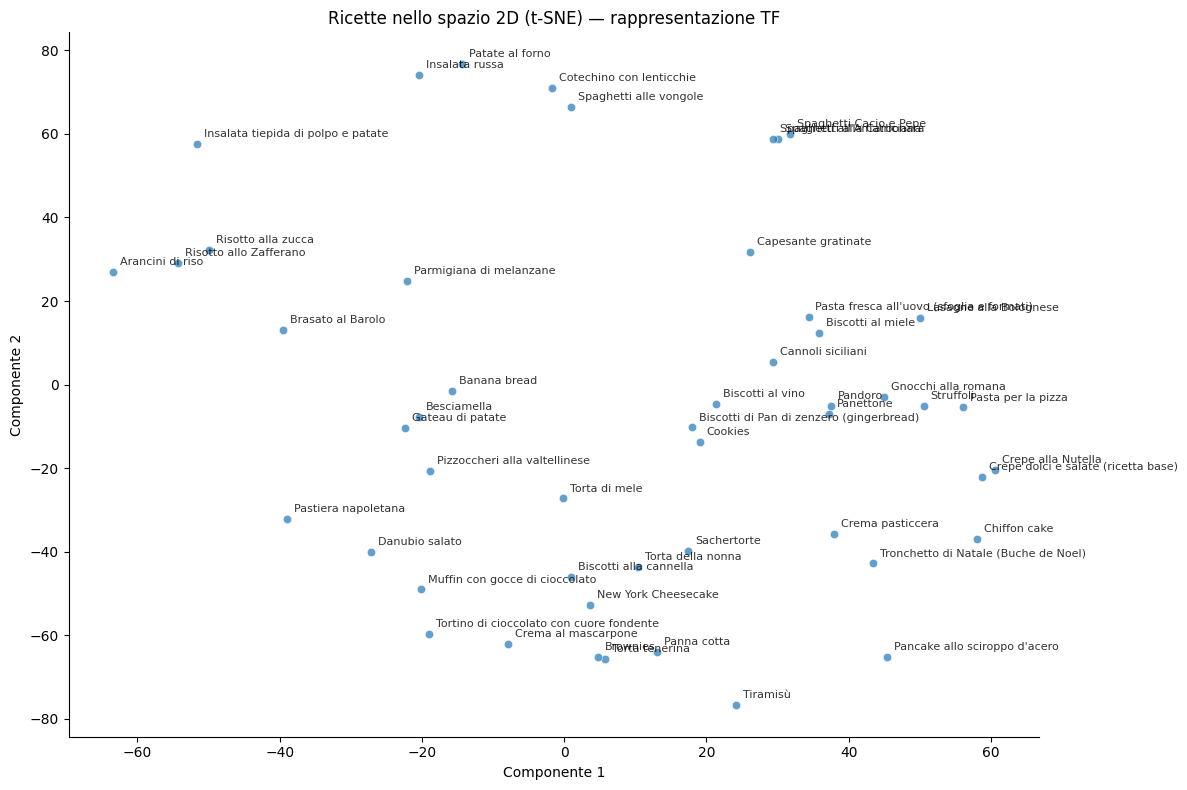

In [8]:
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
X_2d = tsne.fit_transform(X.values)

limit = 50
X_2d_small = X_2d[:limit]

# Build a dataframe for seaborn
plot_df = pd.DataFrame({
    'x': X_2d_small[:, 0],
    'y': X_2d_small[:, 1],
    'title': [index2title[i] for i in range(limit)]
})

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=plot_df, x='x', y='y', ax=ax, alpha=0.7)

for _, row in plot_df.iterrows():
    ax.annotate(row['title'], (row['x'], row['y']),
                fontsize=8, alpha=0.8,
                xytext=(5, 5), textcoords='offset points')

ax.set_title('Ricette nello spazio 2D (t-SNE) — rappresentazione TF')
ax.set_xlabel('Componente 1')
ax.set_ylabel('Componente 2')
sns.despine()
plt.tight_layout()
plt.show()

### Clustering gerarchico agglomerativo

L'idea alla base del **clustering gerarchico agglomerativo** è semplice: partiamo 
dal caso estremo in cui ogni ricetta è un gruppo a sé, e poi procediamo per fusioni 
successive. Ad ogni passo, i due gruppi più simili vengono uniti in uno solo. 
Si continua finché non rimane un unico gruppo che contiene tutte le ricette.

Il risultato non è una singola partizione dei dati, ma una **gerarchia completa di 
raggruppamenti**, dal più specifico (ogni ricetta da sola) al più generale (tutte 
le ricette insieme). Questo è il vantaggio principale rispetto ad altri algoritmi 
di clustering: non dobbiamo decidere in anticipo quanti gruppi vogliamo — la struttura 
emerge dai dati stessi, e possiamo osservarla a diversi livelli di granularità.

Per misurare la similarità tra gruppi — non più tra singoli punti — dobbiamo definire 
un criterio di **linkage**, cioè una regola che stabilisce la distanza tra due insiemi 
di punti. Useremo il **linkage di Ward**, che ad ogni fusione sceglie di unire i due 
gruppi che minimizzano l'aumento della varianza interna: tende a produrre cluster 
compatti e di dimensione equilibrata.

Questa gerarchia di fusioni si rappresenta visivamente con un **dendrogramma**: 
un diagramma ad albero in cui le foglie sono le singole ricette e ogni nodo interno 
rappresenta una fusione. L'altezza a cui due rami si uniscono indica la distanza 
a cui quella fusione è avvenuta — fusioni basse uniscono ricette molto simili, 
fusioni alte uniscono gruppi già abbastanza distanti. Tagliando il dendrogramma 
ad una certa altezza otteniamo una partizione del dataset in un numero di cluster 
che possiamo scegliere *a posteriori*, dopo aver osservato la struttura.

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage

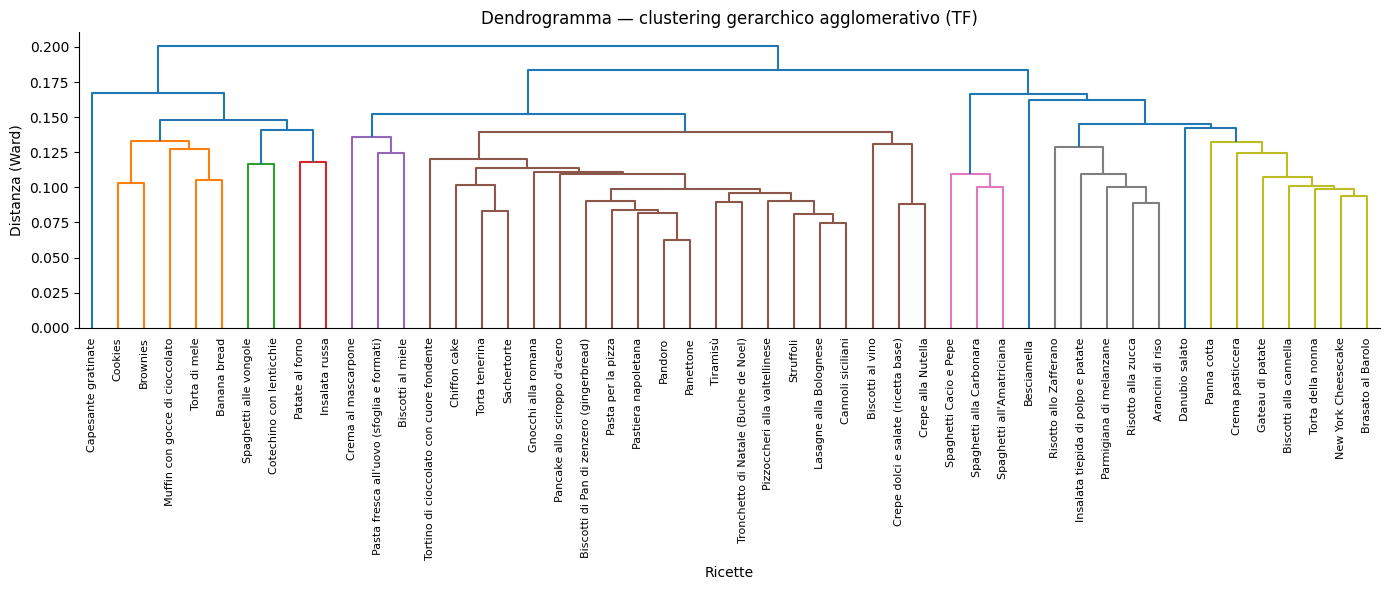

In [10]:
limit = 50

# Apply limit
X_cluster = X.iloc[:limit] if limit else X
titles_cluster = [index2title[i] for i in range(len(X_cluster))]

# Compute hierarchical clustering with Ward linkage
Z = linkage(X_cluster.values, method='ward')

# Plot dendrogram
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    labels=titles_cluster,
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax
)

ax.set_title('Dendrogramma — clustering gerarchico agglomerativo (TF)')
ax.set_xlabel('Ricette')
ax.set_ylabel('Distanza (Ward)')
sns.despine()
plt.tight_layout()
plt.show()

In [11]:
from scipy.cluster.hierarchy import fcluster

In [12]:
cut_threshold = 0.12

# Assign cluster labels
cluster_labels = fcluster(Z, t=cut_threshold, criterion='distance')

# Build cluster dictionary: {cluster_id: [recipe titles]}
clusters = {}
for idx, cluster_id in enumerate(cluster_labels):
    clusters.setdefault(cluster_id, []).append(titles_cluster[idx])

# Inspect clusters
print(f"Number of clusters at threshold {cut_threshold}: {len(clusters)}\n")
for cluster_id, titles in sorted(clusters.items()):
    print(f"Cluster {cluster_id} ({len(titles)} ricette):")
    for title in titles:
        print(f"  - {title}")
    print()

Number of clusters at threshold 0.12: 21

Cluster 1 (2 ricette):
  - Cookies
  - Brownies

Cluster 2 (2 ricette):
  - Torta di mele
  - Banana bread

Cluster 3 (1 ricette):
  - Muffin con gocce di cioccolato

Cluster 4 (2 ricette):
  - Spaghetti alle vongole
  - Cotechino con lenticchie

Cluster 5 (2 ricette):
  - Patate al forno
  - Insalata russa

Cluster 6 (1 ricette):
  - Capesante gratinate

Cluster 7 (1 ricette):
  - Pasta fresca all'uovo (sfoglia e formati)

Cluster 8 (1 ricette):
  - Biscotti al miele

Cluster 9 (1 ricette):
  - Crema al mascarpone

Cluster 10 (16 ricette):
  - Tiramisù
  - Pancake allo sciroppo d'acero
  - Lasagne alla Bolognese
  - Pasta per la pizza
  - Biscotti di Pan di zenzero (gingerbread)
  - Cannoli siciliani
  - Torta tenerina
  - Struffoli
  - Gnocchi alla romana
  - Sachertorte
  - Pastiera napoletana
  - Chiffon cake
  - Tronchetto di Natale (Buche de Noel)
  - Pandoro
  - Pizzoccheri alla valtellinese
  - Panettone

Cluster 11 (1 ricette):
  - Tor

### Dal conteggio al peso: TF-IDF

Osservando i termini che dominano i nostri vettori TF, emerge un problema chiaro: 
le parole più frequenti non sono le più *informative*. Termini come "aggiungete", 
"versate", "mescolate" compaiono in quasi tutte le ricette — hanno una frequenza 
alta, ma ci dicono poco su cosa distingue una ricetta dall'altra.

Il problema non riguarda solo le parole grammaticali come articoli e preposizioni: 
esiste una classe di termini specifici del dominio culinario che sono ugualmente 
poco informativi proprio perché **troppo diffusi**. Per catturare questa idea 
introduciamo il concetto di **Document Frequency**.

#### Document Frequency (DF)

La *document frequency* di un termine $t$ è semplicemente il numero di documenti 
del corpus in cui $t$ compare almeno una volta:

$$df(t) = |\{d \in D : t \in d\}|$$

Un termine con $df$ alta è presente in molti documenti: è poco selettivo, e quindi 
poco utile per distinguere un documento dall'altro. Un termine con $df$ bassa è 
raro nel corpus: quando compare, porta informazione specifica.

#### Inverse Document Frequency (IDF)

Per trasformare questa intuizione in un peso numerico, definiamo l'**Inverse Document 
Frequency**: l'inverso della document frequency, normalizzato sul numero totale di 
documenti $|D|$:

$$idf(t) = \frac{|D|}{df(t)}$$

Più un termine è diffuso, più il suo IDF si avvicina a 1. Più è raro, più IDF cresce. 
Il problema di questa formulazione è che la crescita è troppo ripida: un termine 
presente in un solo documento su mille avrebbe un peso mille volte superiore a uno 
presente ovunque. Questa sproporzione renderebbe i vettori dominati da termini 
rarissimi, magari errori di battitura o parole hapax, che non portano informazione 
utile.

Per comprimere questa dinamica si applica il **logaritmo**:

$$idf(t) = \log\frac{|D|}{df(t)}$$

Il logaritmo preserva l'ordinamento — i termini rari pesano comunque più di quelli 
comuni — ma attenua le differenze estreme, rendendo la scala più equilibrata. 
Lo si vede chiaramente confrontando l'andamento delle due curve al variare di $df$.

#### TF-IDF

Combinando le due componenti otteniamo il peso **TF-IDF**: per ogni termine $t$ 
in ogni documento $d$, il peso è il prodotto della sua frequenza nel documento 
per la sua rarità nel corpus:

$$tfidf(t, d) = tf(t, d) \times idf(t)$$

Un termine ottiene peso alto solo se è frequente *in quel documento* **e** raro 
*nel corpus generale*: esattamente la proprietà che vogliamo per distinguere 
le ricette tra loro.

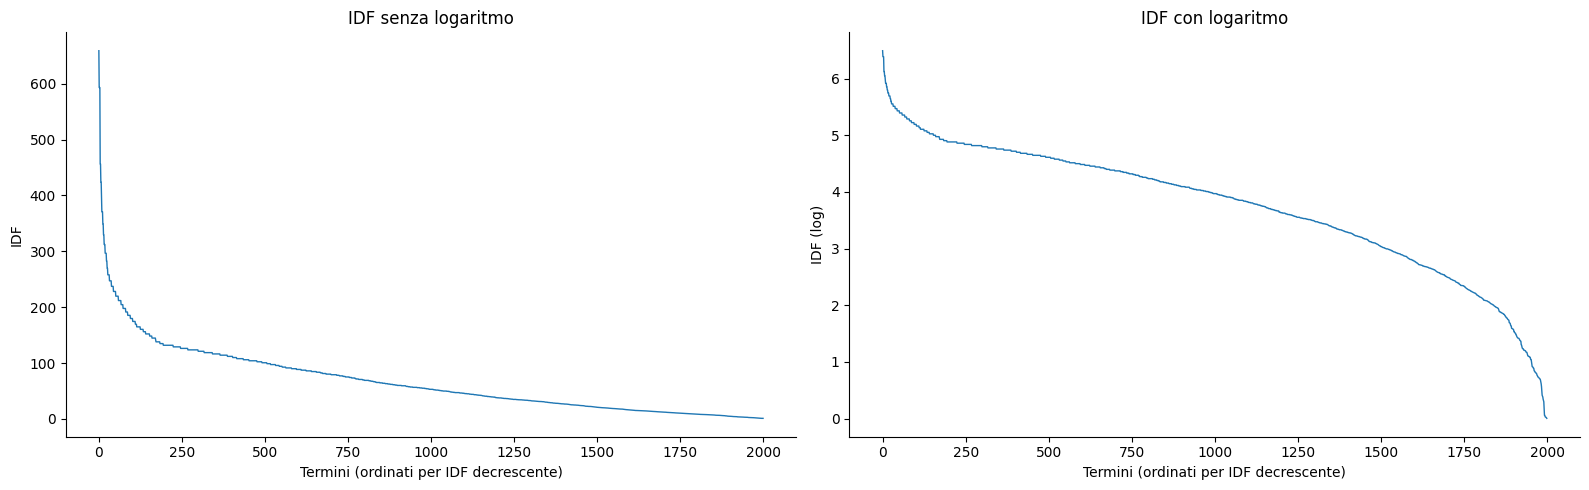

--- 10 termini con IDF più basso (più diffusi nel corpus) ---
  poi                       idf=0.298
  le                        idf=0.155
  una                       idf=0.058
  un                        idf=0.058
  la                        idf=0.035
  con                       idf=0.026
  in                        idf=0.025
  il                        idf=0.022
  di                        idf=0.014
  per                       idf=0.005

--- 10 termini con IDF più alto (più specifici) ---
  zuccotto                  idf=6.491
  zeppole                   idf=6.386
  cous                      idf=6.386
  couscous                  idf=6.386
  tofu                      idf=6.123
  polpettone                idf=6.123
  fregola                   idf=6.049
  scarola                   idf=6.049
  quinoa                    idf=5.980
  orata                     idf=5.916


In [13]:
# Number of documents
N = len(X)

# Compute document frequency: number of documents where each term appears at least once
df_values = (X.values > 0).sum(axis=0)

# IDF without log
idf_raw = N / df_values

# IDF with log
idf_log = np.log(N / df_values)

# Sort both by descending IDF (raw)
sorted_indices = np.argsort(idf_raw)[::-1]
idf_raw_sorted = idf_raw[sorted_indices]
idf_log_sorted = idf_log[sorted_indices]
x_positions = np.arange(len(sorted_indices))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: IDF without log
sns.lineplot(x=x_positions, y=idf_raw_sorted, ax=axes[0], linewidth=1)
axes[0].set_title('IDF senza logaritmo')
axes[0].set_xlabel('Termini (ordinati per IDF decrescente)')
axes[0].set_ylabel('IDF')

# Right: IDF with log
sns.lineplot(x=x_positions, y=idf_log_sorted, ax=axes[1], linewidth=1)
axes[1].set_title('IDF con logaritmo')
axes[1].set_xlabel('Termini (ordinati per IDF decrescente)')
axes[1].set_ylabel('IDF (log)')

sns.despine()
plt.tight_layout()
plt.show()

# Print the 10 lowest IDF terms (most diffuse) and 10 highest (most specific)
vocab_array = np.array(vocab)
print("--- 10 termini con IDF più basso (più diffusi nel corpus) ---")
for term, val in zip(vocab_array[sorted_indices[-10:]], idf_log_sorted[-10:]):
    print(f"  {term:<25} idf={val:.3f}")

print("\n--- 10 termini con IDF più alto (più specifici) ---")
for term, val in zip(vocab_array[sorted_indices[:10]], idf_log_sorted[:10]):
    print(f"  {term:<25} idf={val:.3f}")

### Applichiamo Tf-Idf come criterio di peso dei token nella vettorizzazione

In [14]:
tfidf_matrix = tf_matrix * idf_log
X_tfidf = pd.DataFrame(tfidf_matrix, columns=vocab)

Parole più rilevanti della prima ricetta col nuovo criterio

In [15]:
X_tfidf.iloc[0].sort_values(ascending=False).head(10)

savoiardi      0.066296
mascarpone     0.051790
tiramisù       0.044441
albumi         0.039843
crema          0.034253
caffè          0.033846
pirofila       0.024095
restante       0.023436
strato         0.023242
distribuite    0.023220
Name: 0, dtype: float64

### Applichiamo la procedura di clustering ai nuovi vettori

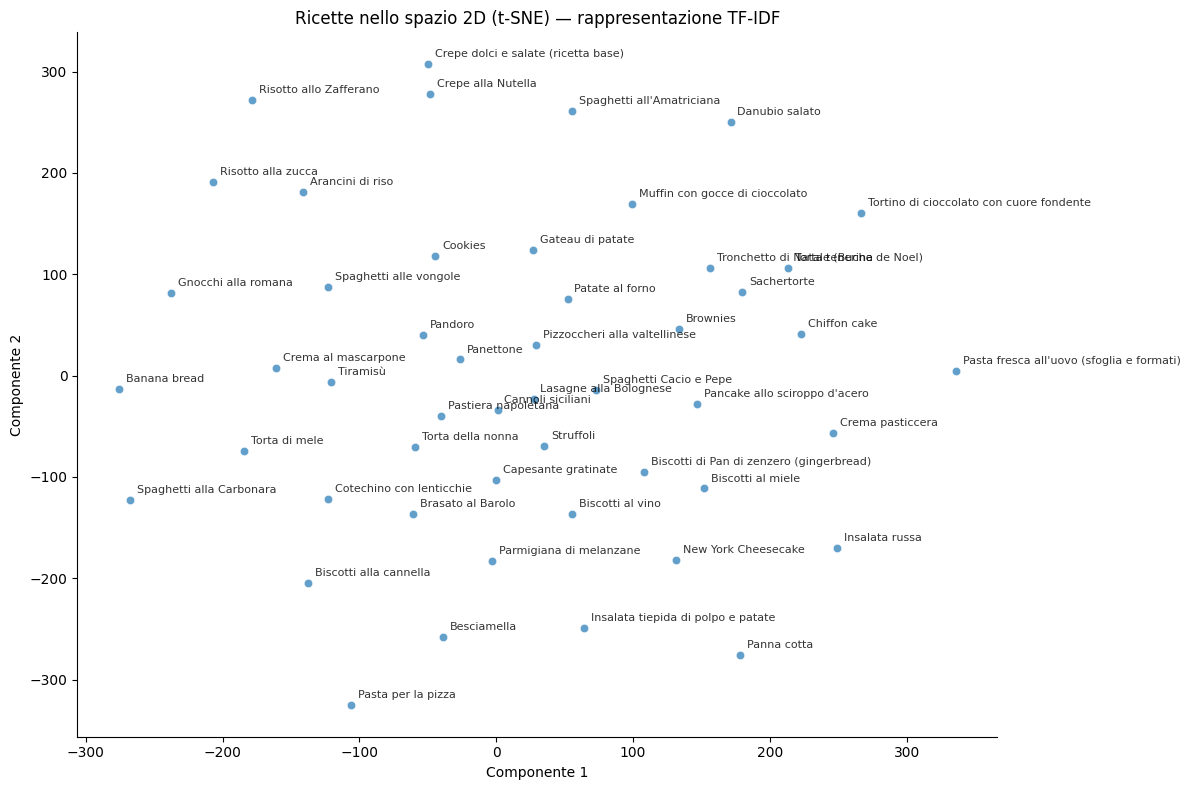

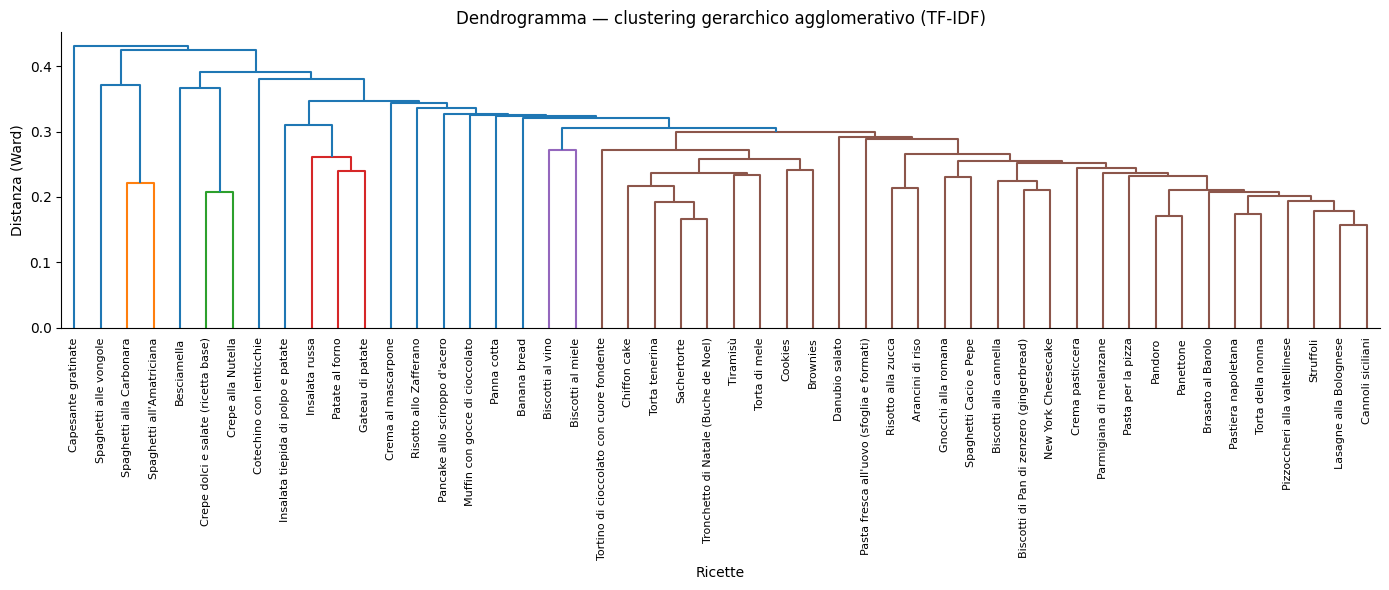

In [16]:
limit = 50

# Apply limit
X_cluster = X_tfidf.iloc[:limit] if limit else X_tfidf
titles_cluster = [index2title[i] for i in range(len(X_cluster))]

# --- t-SNE ---
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
X_2d = tsne.fit_transform(X_cluster.values)

plot_df = pd.DataFrame({
    'x': X_2d[:, 0],
    'y': X_2d[:, 1],
    'title': titles_cluster
})

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=plot_df, x='x', y='y', ax=ax, alpha=0.7)
for _, row in plot_df.iterrows():
    ax.annotate(row['title'], (row['x'], row['y']),
                fontsize=8, alpha=0.8,
                xytext=(5, 5), textcoords='offset points')
ax.set_title('Ricette nello spazio 2D (t-SNE) — rappresentazione TF-IDF')
ax.set_xlabel('Componente 1')
ax.set_ylabel('Componente 2')
sns.despine()
plt.tight_layout()
plt.show()

# --- Hierarchical clustering ---
Z = linkage(X_cluster.values, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, labels=titles_cluster, leaf_rotation=90, leaf_font_size=8, ax=ax)
ax.set_title('Dendrogramma — clustering gerarchico agglomerativo (TF-IDF)')
ax.set_xlabel('Ricette')
ax.set_ylabel('Distanza (Ward)')
sns.despine()
plt.tight_layout()
plt.show()

In [17]:
cut_threshold = 0.38


# --- Flat clusters ---
cluster_labels = fcluster(Z, t=cut_threshold, criterion='distance')

clusters = {}
for idx, cluster_id in enumerate(cluster_labels):
    clusters.setdefault(cluster_id, []).append(titles_cluster[idx])

print(f"Numero di cluster alla soglia {cut_threshold}: {len(clusters)}\n")
for cluster_id, titles in sorted(clusters.items()):
    print(f"Cluster {cluster_id} ({len(titles)} ricette):")
    print(", ".join(titles))
    print()

Numero di cluster alla soglia 0.38: 5

Cluster 1 (3 ricette):
Spaghetti alla Carbonara, Spaghetti alle vongole, Spaghetti all'Amatriciana

Cluster 2 (3 ricette):
Crepe dolci e salate (ricetta base), Besciamella, Crepe alla Nutella

Cluster 3 (42 ricette):
Tiramisù, Cookies, Pancake allo sciroppo d'acero, Crema al mascarpone, Lasagne alla Bolognese, Pasta per la pizza, Biscotti di Pan di zenzero (gingerbread), New York Cheesecake, Tortino di cioccolato con cuore fondente, Crema pasticcera, Brasato al Barolo, Muffin con gocce di cioccolato, Cannoli siciliani, Torta tenerina, Brownies, Patate al forno, Pasta fresca all'uovo (sfoglia e formati), Biscotti al vino, Torta di mele, Struffoli, Insalata russa, Gnocchi alla romana, Risotto alla zucca, Sachertorte, Biscotti al miele, Pastiera napoletana, Chiffon cake, Tronchetto di Natale (Buche de Noel), Panna cotta, Torta della nonna, Pandoro, Pizzoccheri alla valtellinese, Gateau di patate, Spaghetti Cacio e Pepe, Parmigiana di melanzane, Insal

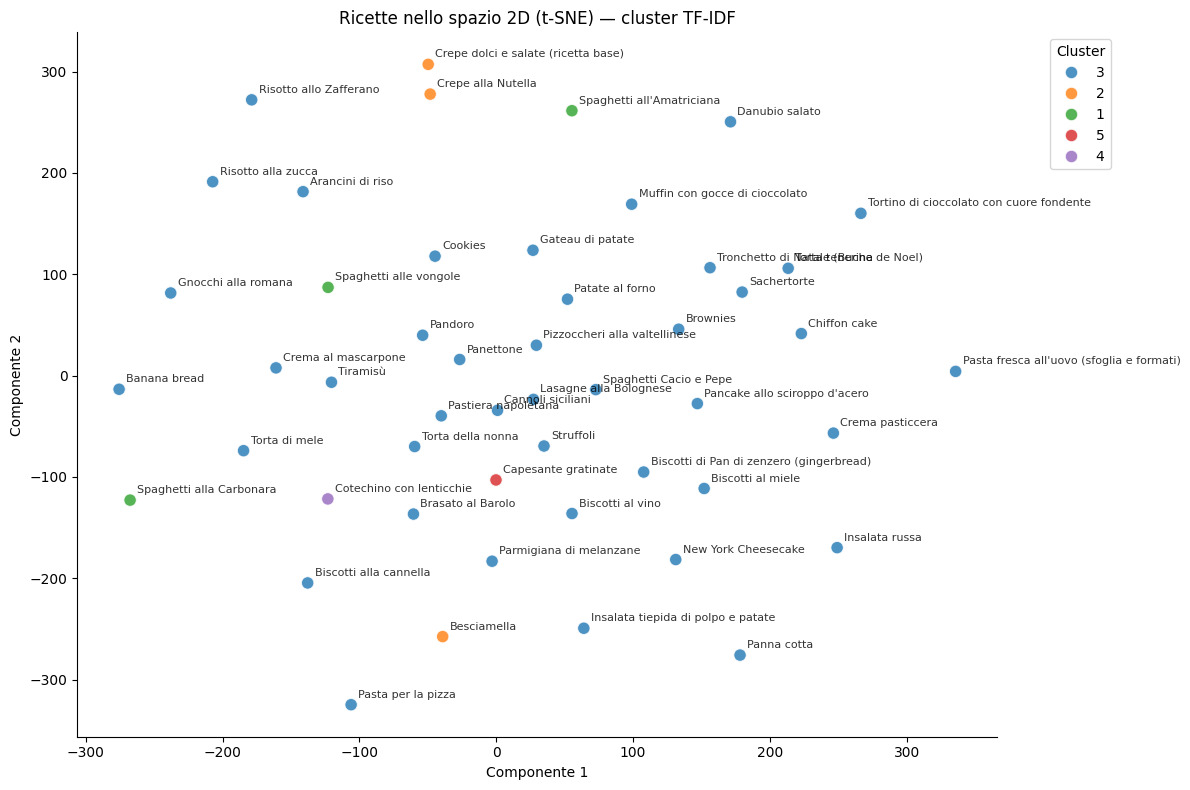

In [18]:
# --- t-SNE colored by cluster ---
plot_df['cluster'] = cluster_labels.astype(str)

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=plot_df, x='x', y='y', hue='cluster',
                palette='tab10', ax=ax, alpha=0.8, s=80)
for _, row in plot_df.iterrows():
    ax.annotate(row['title'], (row['x'], row['y']),
                fontsize=8, alpha=0.8,
                xytext=(5, 5), textcoords='offset points')
ax.set_title('Ricette nello spazio 2D (t-SNE) — cluster TF-IDF')
ax.set_xlabel('Componente 1')
ax.set_ylabel('Componente 2')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

### Esempio completo

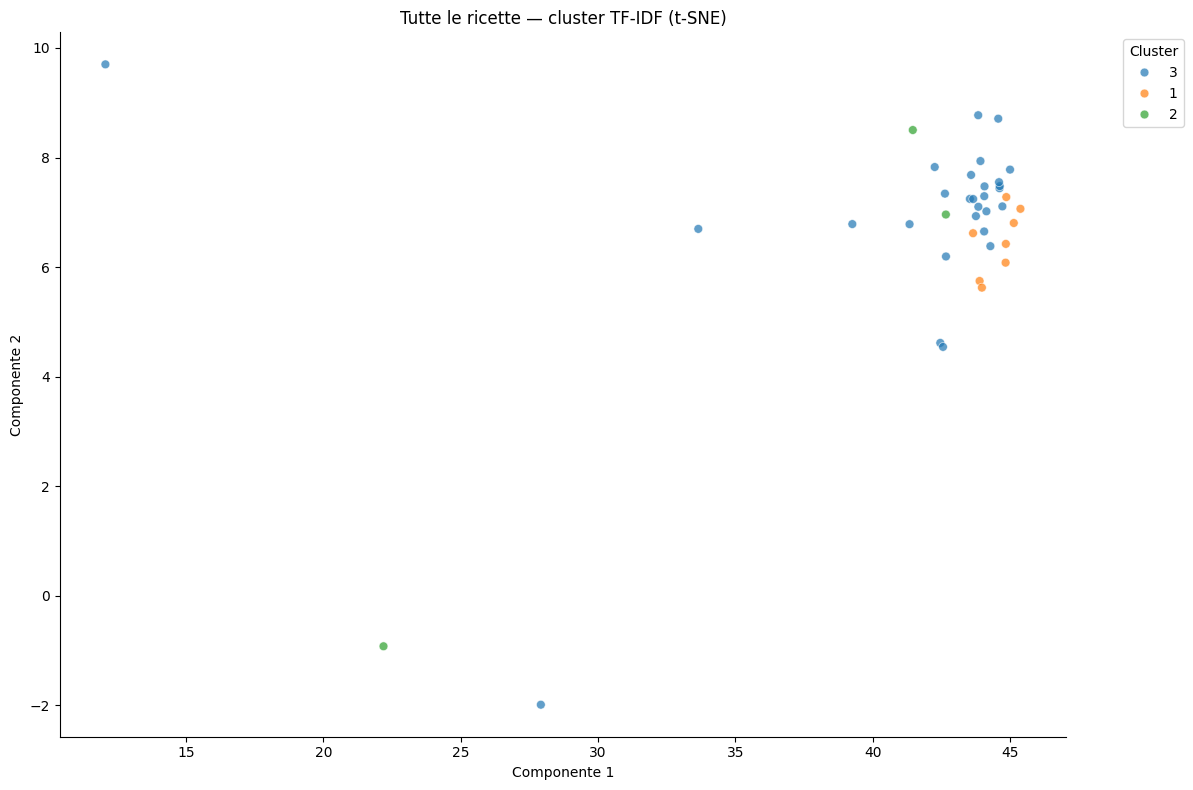


Cluster 1 (8 ricette):
  - Crema al caffè
  - Panna cotta al caffè
  - Sorbetto al caffè
  - Granita al caffè con panna
  - Cioccolata calda al caffè
  - Biscottata calda al caffè
  - Gelato panna e caffè
  - Caffè goloso con panna

Cluster 2 (3 ricette):
  - Irish coffee
  - Tiramisù alle 5 spezie
  - Cioccolatte bianco

Cluster 3 (28 ricette):
  - Biscotti senza burro
  - Cheesecake al caffè
  - Torta all'acqua al caffè
  - Rotolo dolce senza cottura
  - Semifreddo al caffè
  - Torta tenerina al caffè
  - Biscotti chicco di caffè
  - Sbriciolata al cappuccino e cioccolato
  - Dessert di panna e ricotta al caffè
  - Torta al caffè
  - Crostata morbida al tiramisù
  - Dolce latte
  - Crostata morbida al caffè
  - Mini cheesecake al caffè
  - Crema diplomatica al caffè
  - Cremoso al caffè con biscotto alle mandorle
  - Mousse al caffè
  - Filetto in crosta con salsa al Porto e aria di caffè
  - Sfogliatine al caffè
  - Bacetti alla crema di caffè
  - Torta spirale al caffè
  - Delizie

In [19]:
# Compute hierarchical clustering on full TF-IDF matrix
Z_full = linkage(X_tfidf.values, method='ward')
cluster_labels_full = fcluster(Z_full, t=cut_threshold, criterion='distance')

# t-SNE on full dataset
tsne_full = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d_full = tsne_full.fit_transform(X_tfidf.values)

plot_df_full = pd.DataFrame({
    'x': X_2d_full[:, 0],
    'y': X_2d_full[:, 1],
    'cluster': cluster_labels_full.astype(str)
})

# Add recipe titles to full dataframe
titles_full = [index2title[i] for i in range(len(X_tfidf))]
plot_df_full['title'] = titles_full

# --- Cluster selection ---
# Set to None to show all clusters, or specify a list of cluster ids to filter
selected_clusters = ['1', '2', '3']

# Filter if selection is active
if selected_clusters:
    mask = plot_df_full['cluster'].isin(selected_clusters)
    plot_df_viz = plot_df_full[mask].copy()
else:
    plot_df_viz = plot_df_full.copy()

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=plot_df_viz, x='x', y='y', hue='cluster',
                palette='tab10', ax=ax, alpha=0.7, s=40)
ax.set_title('Tutte le ricette — cluster TF-IDF (t-SNE)')
ax.set_xlabel('Componente 1')
ax.set_ylabel('Componente 2')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

# --- Print recipe titles for selected clusters ---
clusters_to_print = selected_clusters if selected_clusters else sorted(plot_df_full['cluster'].unique())
for cluster_id in clusters_to_print:
    titles_in_cluster = plot_df_full[plot_df_full['cluster'] == cluster_id]['title'].tolist()
    print(f"\nCluster {cluster_id} ({len(titles_in_cluster)} ricette):")
    for title in titles_in_cluster:
        print(f"  - {title}")

## Apprendimento per rinforzo

Nel paradigma che abbiamo visto finora, il modello riceve dati e impara da essi. 
Nell'**apprendimento per rinforzo** la struttura è 
diversa: non esiste un dataset di partenza. Esiste un **agente** che interagisce 
con un **ambiente**, compie **azioni** e riceve in risposta un **reward** — un segnale 
numerico che indica quanto quella scelta è stata vantaggiosa.

L'obiettivo dell'agente non è massimizzare il reward di una singola azione, ma 
imparare una **politica** — una strategia che, nel corso di molte interazioni, 
massimizza il reward *cumulativo* nel tempo. Questo implica che l'agente debba 
talvolta accettare una scelta subottimale nel breve periodo per ottenere un 
vantaggio maggiore in seguito.

Il ciclo fondamentale è sempre lo stesso: l'agente osserva lo **stato** corrente 
dell'ambiente, sceglie un'azione, riceve un reward e osserva il nuovo stato. 
Questo ciclo si ripete per molti **episodi**, e ad ogni iterazione l'agente 
aggiorna la propria conoscenza.

Esistono molti algoritmi di apprendimento per rinforzo, che si differenziano 
principalmente per come rappresentano e aggiornano la conoscenza acquisita. 
Alcuni lavorano direttamente sulla politica, cercando di migliorarla passo dopo 
passo. Altri stimano il valore atteso del reward futuro per ogni coppia 
stato-azione, e derivano la politica da questa stima.

Noi useremo **Q-learning**, che appartiene a questa seconda famiglia. L'idea 
centrale è costruire una **Q-table**: una tabella in cui ogni riga è uno stato 
possibile dell'ambiente e ogni colonna è un'azione disponibile. Ogni cella 
contiene il valore $Q(s, a)$, la stima del reward cumulativo atteso se 
l'agente si trova nello stato $s$ e compie l'azione $a$, agendo poi in modo 
ottimale.

La tabella viene aggiornata ad ogni step secondo la regola:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Il termine tra parentesi si chiama **errore TD** (*Temporal Difference*): è la 
differenza tra il valore stimato attuale $Q(s, a)$ e una stima migliore costruita 
usando il reward appena ricevuto $r$ e il valore massimo raggiungibile dallo stato 
successivo $s'$. Il parametro $\alpha$ controlla la velocità di apprendimento, 
mentre $\gamma$, detto **fattore di sconto**, bilancia l'importanza del reward 
immediato rispetto a quello futuro.

Scegliamo Q-learning perché la sua struttura tabulare rende il processo di 
apprendimento completamente trasparente: potremo osservare la Q-table prima, 
durante e dopo il training, e leggere direttamente cosa ha imparato l'agente.

### Il Cuoco: costruire un menu con l'apprendimento per rinforzo

Per esplorare il Q-learning costruiamo un esempio concreto: un agente — il nostro 
**Cuoco** — deve imparare a comporre un menu completo scegliendo un piatto per 
ciascuna delle quattro portate tradizionali: antipasto, primo, secondo e dolce.

All'inizio il Cuoco non sa nulla di cucina. Ad ogni portata sceglie un piatto 
a caso dalla lista disponibile, e riceve un feedback immediato: ha scelto qualcosa 
di appropriato per quella portata, oppure no? Nel tempo, accumulando esperienza 
su molti menu, impara ad associare ogni portata ai piatti più adatti.

**Gli stati** del gioco sono le quattro portate, affrontate in sequenza:

$$antipasto \rightarrow primo \rightarrow secondo \rightarrow dolce$$

Ma lo stato non è solo la portata corrente: include anche quali ingredienti principali 
sono già stati usati nelle portate precedenti. Questo perché le scelte non sono 
indipendenti — scegliere un piatto a base di pasta come primo esclude di fatto 
piatti simili nelle portate successive, penalizzando la varietà del menu. 
Lo stato è quindi la coppia *(portata corrente, insieme degli ingredienti già usati)*.

**Le azioni** disponibili sono sempre le stesse dieci, indipendentemente dalla 
portata corrente:

| | Piatto | Ingrediente principale |
|---|---|---|
| 0 | Bruschetta | pane |
| 1 | Pasta al pomodoro | pasta |
| 2 | Risotto ai funghi | riso |
| 3 | Bistecca alla fiorentina | carne |
| 4 | Salmone al forno | pesce |
| 5 | Insalata caprese | verdura |
| 6 | Tiramisù | uova |
| 7 | Panna cotta | panna |
| 8 | Minestrone | verdura |
| 9 | Frittata | uova |

Il **reward** che il Cuoco riceve ad ogni scelta combina due componenti: 
l'appropriatezza del piatto per quella portata — scegliere il Tiramisù come 
antipasto porta un feedback negativo, sceglierlo come dolce porta un feedback 
positivo — e una **penalità** se l'ingrediente principale del piatto scelto 
è già stato usato in una portata precedente. Questo crea una tensione reale 
tra le scelte: un piatto ottimo per la portata corrente potrebbe rivelarsi 
una scelta miope se occupa un ingrediente che sarebbe stato prezioso più avanti.

La **Q-table** che l'agente costruisce ha una riga per ogni stato possibile — 
ogni combinazione di portata e insieme di ingredienti già usati — e una colonna 
per ciascuna delle dieci azioni disponibili. Le righe raccontano storie diverse: 
il valore di scegliere la Pasta al pomodoro come primo cambia a seconda di cosa 
è già stato servito come antipasto. È proprio questa dipendenza tra le scelte 
che rende il problema interessante e giustifica l'uso del Q-learning.

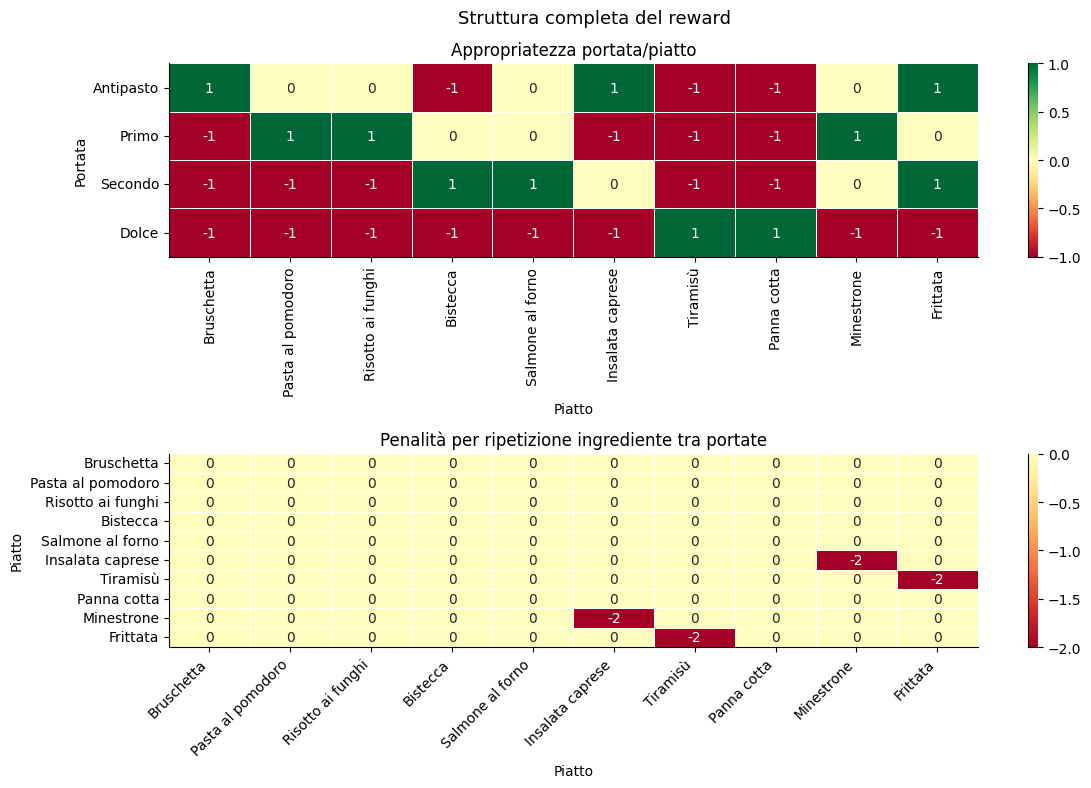

In [20]:
# --- Environment definition ---

COURSES = ['Antipasto', 'Primo', 'Secondo', 'Dolce']
DISHES = [
    'Bruschetta',        # 0
    'Pasta al pomodoro', # 1
    'Risotto ai funghi', # 2
    'Bistecca',          # 3
    'Salmone al forno',  # 4
    'Insalata caprese',  # 5
    'Tiramisù',          # 6
    'Panna cotta',       # 7
    'Minestrone',        # 8
    'Frittata'           # 9
]

N_COURSES = len(COURSES)
N_ACTIONS = len(DISHES)

# Reward table: rows = courses, columns = dishes
# Values reflect culinary appropriateness: +1 good, 0 neutral, -1 wrong
REWARD_TABLE = np.array([
#   Bru  Pom  Ris  Bis  Sal  Cap  Tir  Pan  Min  Fri
    [ 1,   0,   0,  -1,   0,   1,  -1,  -1,   0,   1],  # Antipasto
    [-1,   1,   1,   0,   0,  -1,  -1,  -1,   1,   0],  # Primo
    [-1,  -1,  -1,   1,   1,   0,  -1,  -1,   0,   1],  # Secondo
    [-1,  -1,  -1,  -1,  -1,  -1,   1,   1,  -1,  -1],  # Dolce
], dtype=float)

# Main ingredient per dish — repeated ingredients across courses are penalized
MAIN_INGREDIENTS = {
    0: 'pane',      # Bruschetta
    1: 'pasta',     # Pasta al pomodoro
    2: 'riso',      # Risotto ai funghi
    3: 'carne',     # Bistecca
    4: 'pesce',     # Salmone al forno
    5: 'verdura',   # Insalata caprese
    6: 'uova',      # Tiramisù
    7: 'panna',     # Panna cotta
    8: 'verdura',   # Minestrone
    9: 'uova'       # Frittata
}

# Penalty applied when a chosen dish shares its main ingredient with a previous course
REPETITION_PENALTY = -2.0

def make_state(course_idx, used_ingredients):
    """Build a hashable state from course index and set of used ingredients."""
    return (course_idx, frozenset(used_ingredients))

def get_reward(course_idx, action, used_ingredients):
    """Return the reward for choosing action at the current course.
    Applies a repetition penalty if the dish's main ingredient was already used.
    """
    reward = REWARD_TABLE[course_idx, action]
    if MAIN_INGREDIENTS[action] in used_ingredients:
        reward += REPETITION_PENALTY
    return reward

def is_terminal(course_idx):
    """Return True if the episode is over (all courses assigned)."""
    return course_idx >= N_COURSES

# --- Visualization helpers ---

def plot_reward_table():
    """Display the full reward structure:
    1. base appropriateness (course x dish)
    2. repetition penalty (dish x dish) based on shared main ingredient
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # Left: base appropriateness table
    df_reward = pd.DataFrame(REWARD_TABLE, index=COURSES, columns=DISHES)
    sns.heatmap(df_reward, annot=True, fmt='.0f', cmap='RdYlGn',
                center=0, linewidths=0.5, ax=axes[0])
    axes[0].set_title('Appropriatezza portata/piatto')
    axes[0].set_xlabel('Piatto')
    axes[0].set_ylabel('Portata')
    axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

    # Right: dish x dish repetition penalty matrix
    # cell (i,j) = REPETITION_PENALTY if dishes i and j share the same main ingredient
    penalty_matrix = np.zeros((N_ACTIONS, N_ACTIONS))
    for i in range(N_ACTIONS):
        for j in range(N_ACTIONS):
            if i != j and MAIN_INGREDIENTS[i] == MAIN_INGREDIENTS[j]:
                penalty_matrix[i, j] = REPETITION_PENALTY

    df_penalty = pd.DataFrame(penalty_matrix, index=DISHES, columns=DISHES)
    sns.heatmap(df_penalty, annot=True, fmt='.0f', cmap='RdYlGn',
                center=0, linewidths=0.5, ax=axes[1])
    axes[1].set_title(f'Penalità per ripetizione ingrediente tra portate')
    axes[1].set_xlabel('Piatto')
    axes[1].set_ylabel('Piatto')
    axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

    plt.suptitle('Struttura completa del reward', fontsize=13)
    sns.despine()
    plt.tight_layout()
    plt.show()
    
def plot_q_table(Q, title='Q-table'):
    """Display Q-table as a heatmap, averaged over all states per course.
    Since the state space is now (course, used_ingredients), we show
    the mean Q-values for each course across all visited states.
    """
    # Aggregate Q-values by course index
    course_q = {i: [] for i in range(N_COURSES)}
    for (course_idx, _), q_values in Q.items():
        course_q[course_idx].append(q_values)

    # Build mean Q matrix: rows = courses, columns = dishes
    mean_q = np.zeros((N_COURSES, N_ACTIONS))
    for i in range(N_COURSES):
        if course_q[i]:
            mean_q[i] = np.mean(course_q[i], axis=0)

    df_q = pd.DataFrame(mean_q, index=COURSES, columns=DISHES)
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(df_q, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, ax=ax)
    ax.set_title(f'{title}  (Q-values medi per portata)')
    ax.set_xlabel('Piatto')
    ax.set_ylabel('Portata')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()

def plot_episode_rewards(rewards, window=50):
    """Plot total reward per episode with a rolling average."""
    df_r = pd.DataFrame({'reward': rewards})
    df_r['rolling'] = df_r['reward'].rolling(window=window, min_periods=1).mean()
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.lineplot(data=df_r, x=df_r.index, y='reward',
                 alpha=0.3, color='steelblue', ax=ax, label='reward per episodio')
    sns.lineplot(data=df_r, x=df_r.index, y='rolling',
                 color='steelblue', ax=ax, label=f'media mobile ({window} ep.)')
    ax.set_title('Reward totale per episodio')
    ax.set_xlabel('Episodio')
    ax.set_ylabel('Reward totale')
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

plot_reward_table()

In [21]:
# --- Agent ---

class CookAgent:
    def __init__(self, n_actions, alpha=0.1, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        """
        Q-learning agent with dictionary-based Q-table to support
        the expanded state space (course_idx, used_ingredients).

        alpha:         learning rate
        gamma:         discount factor
        epsilon:       initial exploration rate
        epsilon_decay: multiplicative decay applied after each episode
        epsilon_min:   minimum exploration rate
        """
        self.n_actions     = n_actions
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min   = epsilon_min

        # Q-table as dictionary: state -> np.array of shape (n_actions,)
        self.Q = {}

    def _get_q(self, state):
        """Return Q-values for a state, initializing to zeros if unseen."""
        if state not in self.Q:
            self.Q[state] = np.zeros(self.n_actions)
        return self.Q[state]

    def choose_action(self, state):
        """Epsilon-greedy action selection."""
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)    # explore
        return np.argmax(self._get_q(state))            # exploit

    def update(self, state, action, reward, next_state, terminal):
        """Apply the Q-learning update rule."""
        if terminal:
            td_target = reward
        else:
            td_target = reward + self.gamma * np.max(self._get_q(next_state))

        q_values         = self._get_q(state)
        td_error         = td_target - q_values[action]
        q_values[action] += self.alpha * td_error

    def decay_epsilon(self):
        """Reduce exploration rate after each episode."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def copy_q(self):
        """Return a deep copy of the current Q-table."""
        return {state: q.copy() for state, q in self.Q.items()}


# --- Training loop ---

def train(agent, n_episodes=2000, snapshot_episodes=None):
    """
    Train the agent for n_episodes episodes.
    snapshot_episodes: list of episode numbers at which to save a Q-table snapshot.
    Returns episode rewards and Q-table snapshots.
    """
    if snapshot_episodes is None:
        snapshot_episodes = [1, 10, 50, 100, 500, n_episodes]

    episode_rewards = [0]
    snapshots       = {0: agent.copy_q()}

    for episode in range(1, n_episodes + 1):
        course_idx       = 0
        used_ingredients = set()
        total_reward     = 0

        while not is_terminal(course_idx):
            state      = make_state(course_idx, used_ingredients)
            action     = agent.choose_action(state)
            reward     = get_reward(course_idx, action, used_ingredients)
            next_idx   = course_idx + 1
            terminal   = is_terminal(next_idx)
            next_state = make_state(next_idx, used_ingredients | {MAIN_INGREDIENTS[action]})

            agent.update(state, action, reward, next_state, terminal)

            used_ingredients.add(MAIN_INGREDIENTS[action])
            total_reward += reward
            course_idx = next_idx

        agent.decay_epsilon()
        episode_rewards.append(total_reward)

        if episode in snapshot_episodes:
            snapshots[episode] = agent.copy_q()

    return episode_rewards, snapshots


# --- Run ---
N_EPISODES = 2000

agent = CookAgent(
    n_actions     = N_ACTIONS,
    alpha         = 0.1,
    gamma         = 0.9,
    epsilon       = 1.0,
    epsilon_decay = 0.995,
    epsilon_min   = 0.01
)

episode_rewards, snapshots = train(agent, n_episodes=N_EPISODES, snapshot_episodes=range(N_EPISODES))

### Prima dell'apprendimento

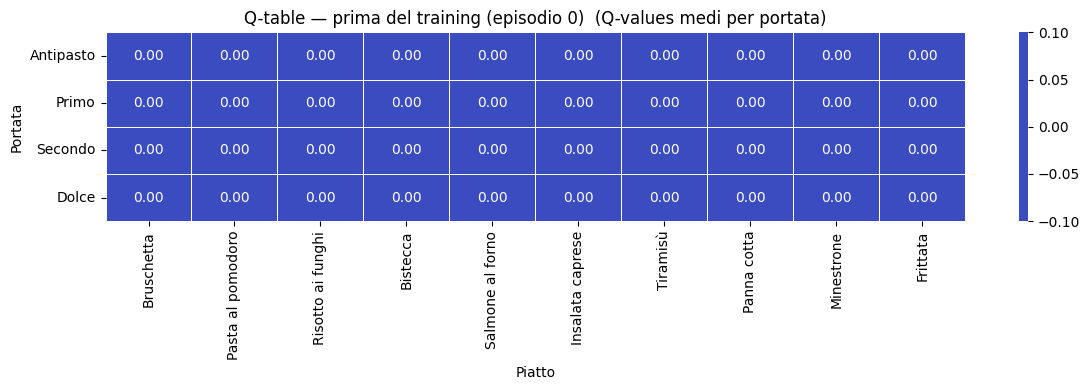

In [22]:
plot_q_table(snapshots[0], title='Q-table — prima del training (episodio 0)')

### Processo di apprendimento

In [23]:
from IPython.display import clear_output
import time 

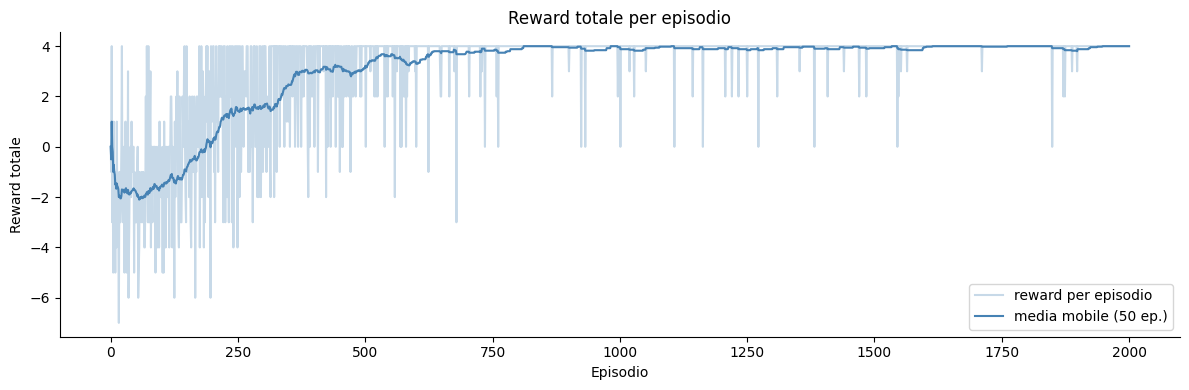

In [24]:
plot_episode_rewards(episode_rewards, window=50)

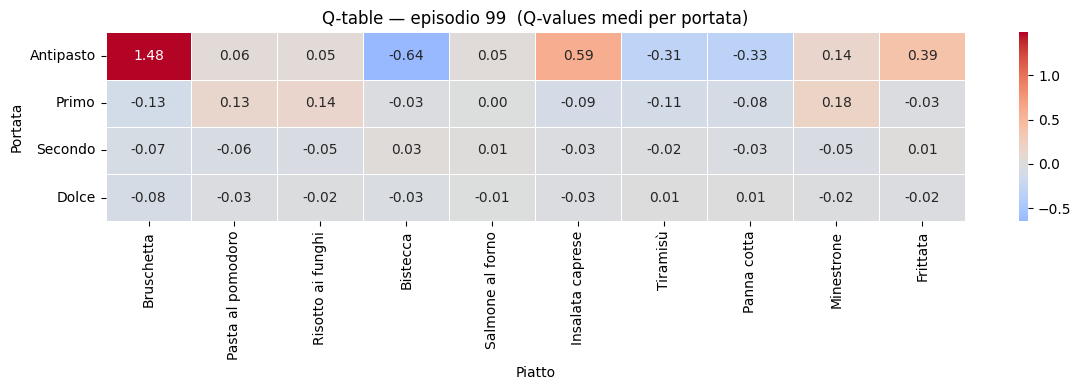

In [25]:
for episode in range(N_EPISODES - 1900):#[0, 1, 10, 50, 100, 500, N_EPISODES]:
    clear_output(wait=True)
    plot_q_table(snapshots[episode], title=f'Q-table — episodio {episode}')
    time.sleep(0)


### Il cuoco all'opera

In [26]:
def serve_meal(agent, delay=1.5):
    """
    Use the trained agent to compose a full meal step by step using greedy policy.
    Prints each choice with a delay to simulate a narrative animation.
    """
    course_idx       = 0
    used_ingredients = set()
    menu             = []
    total_reward     = 0

    print("=" * 55)
    print("       🍽️  IL CUOCO COMPONE IL MENU  🍽️")
    print("=" * 55)
    time.sleep(delay)

    while not is_terminal(course_idx):
        state    = make_state(course_idx, used_ingredients)
        q_values = agent._get_q(state)
        action   = np.argmax(q_values)
        reward   = get_reward(course_idx, action, used_ingredients)

        # Show deliberation
        clear_output(wait=True)
        print("=" * 55)
        print("       🍽️  IL CUOCO COMPONE IL MENU  🍽️")
        print("=" * 55)
        for past_course, past_action in zip(COURSES[:course_idx], menu):
            print(f"\n  {past_course:<12} →  {DISHES[past_action]}")
        print(f"\n  {COURSES[course_idx]:<12} →  ...")
        print(f"\n  Il Cuoco considera:")
        for i, (dish, q) in enumerate(zip(DISHES, q_values)):
            marker = " ← scelta" if i == action else ""
            print(f"  {dish:<25} Q={q:+.2f}{marker}")

        time.sleep(delay)

        # Show choice
        clear_output(wait=True)
        print("=" * 55)
        print("       🍽️  IL CUOCO COMPONE IL MENU  🍽️")
        print("=" * 55)
        for past_course, past_action in zip(COURSES[:course_idx], menu):
            print(f"\n  {past_course:<12} →  {DISHES[past_action]}")
        print(f"\n  {COURSES[course_idx]:<12} →  {DISHES[action]}  (reward: {reward:+.1f})")

        used_ingredients.add(MAIN_INGREDIENTS[action])
        menu.append(action)
        total_reward += reward
        course_idx += 1

        time.sleep(delay)

    # Final summary
    clear_output(wait=True)
    print("=" * 55)
    print("       🍽️  IL MENU È PRONTO  🍽️")
    print("=" * 55)
    for course, action in zip(COURSES, menu):
        print(f"\n  {course:<12} →  {DISHES[action]}")
    print(f"\n  Reward totale: {total_reward:+.1f}")
    print("=" * 55)

serve_meal(agent, delay=1.5)

       🍽️  IL MENU È PRONTO  🍽️

  Antipasto    →  Bruschetta

  Primo        →  Risotto ai funghi

  Secondo      →  Bistecca

  Dolce        →  Tiramisù

  Reward totale: +4.0


### Esplorazione e temperatura

Un agente completamente greedy sceglie sempre il piatto con Q-value più alto — 
ma questo lo rende prevedibile e rigido. Esiste un modo più sfumato di usare 
la Q-table: invece di prendere sempre il massimo, possiamo **campionare** un'azione 
usando i Q-value come base per una distribuzione di probabilità.

Lo strumento è la funzione **softmax**, parametrizzata da un valore $\tau$ detto 
**temperatura**:

$$P(a | s) = \frac{e^{Q(s,a) / \tau}}{\sum_{a'} e^{Q(s,a') / \tau}}$$

La temperatura controlla quanto la distribuzione è concentrata:
- con $\tau$ **bassa** (es. 0.1) il softmax amplifica le differenze — la probabilità 
si concentra quasi tutta sull'azione migliore, comportamento simile al greedy
- con $\tau$ **alta** (es. 5.0) il softmax appiattisce le differenze — tutte le 
azioni diventano quasi equiprobabili, comportamento simile alla scelta casuale
- con $\tau = 1.0$ i Q-value vengono usati direttamente come logit

Questo meccanismo ci permette di regolare quanta **creatività** vogliamo nel menu: 
un Cuoco con temperatura alta sorprenderà di più, uno con temperatura bassa sarà 
più affidabile.

In [28]:
temperatures = [0.1, 5.0]

def softmax(q_values, temperature=1.0):
    """Convert Q-values to a probability distribution using softmax with temperature."""
    q_shifted = q_values - np.max(q_values)  # numerical stability
    exp_q     = np.exp(q_shifted / temperature)
    return exp_q / exp_q.sum()

**Esempio con softmax**

In [45]:
values = np.array([15, 25, 3, 16])
print("Valori:", values)
#print("Frazione:", np.round(values / values.sum(), 3))
print("Softmax (t=1):", np.round(softmax(values), 3))
print("Softmax (t=8):", np.round(softmax(values, temperature=28), 3))

Valori: [15 25  3 16]
Softmax (t=1): [0. 1. 0. 0.]
Softmax (t=8): [0.243 0.347 0.158 0.252]


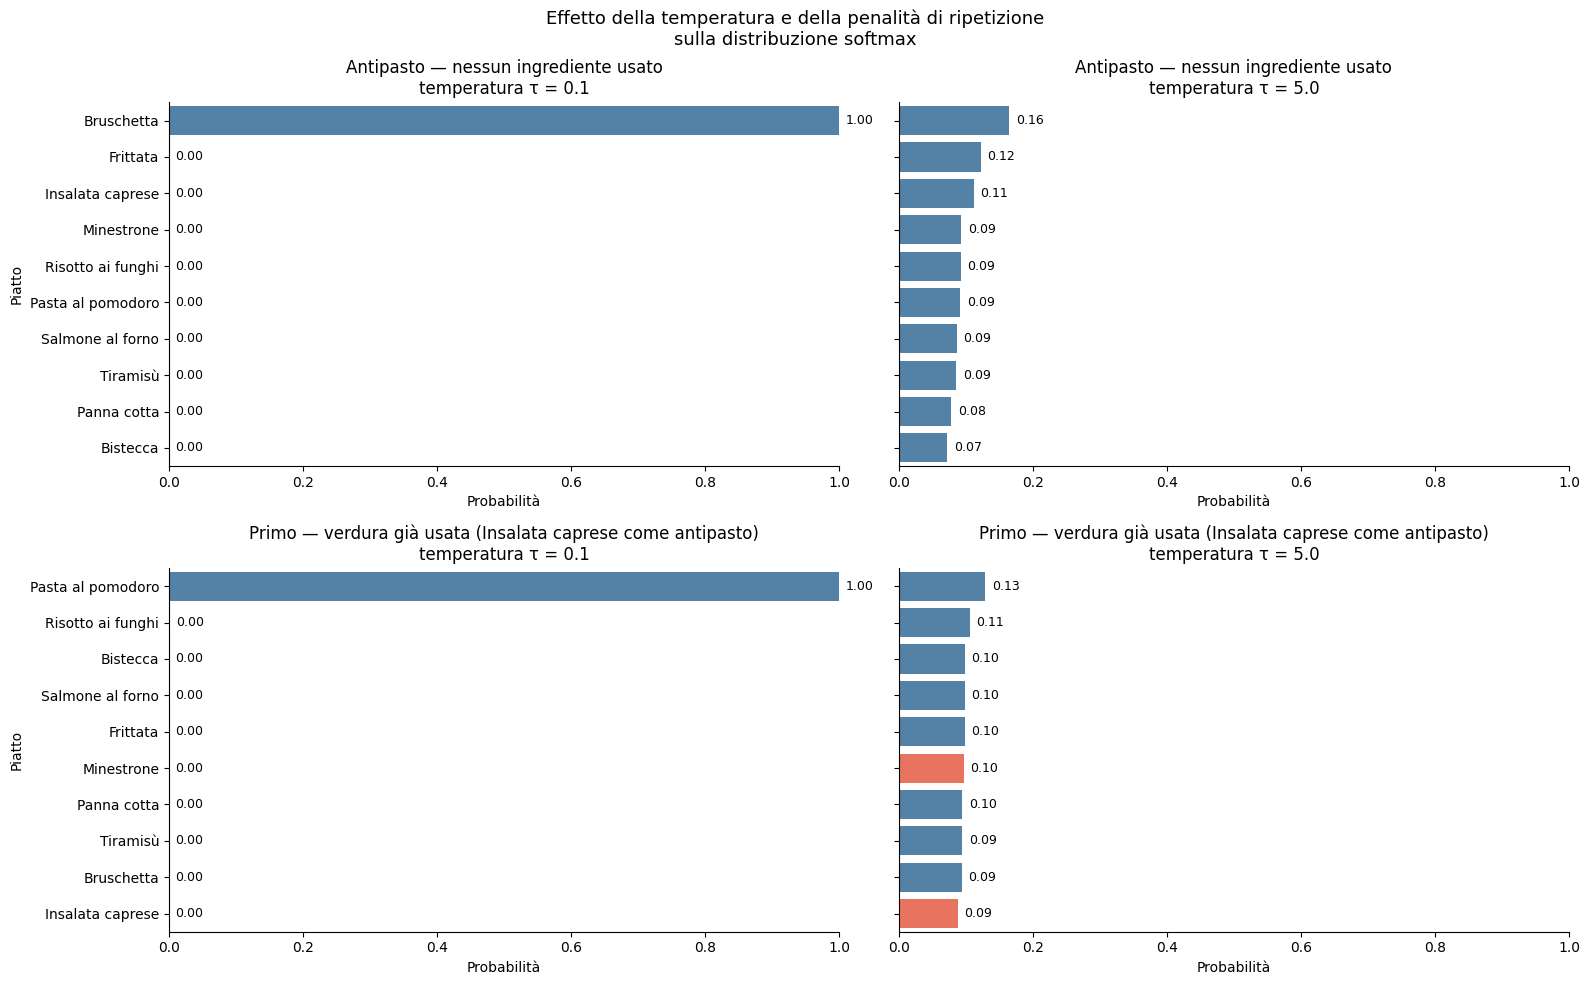

In [46]:


fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey='row')

scenarios = [
    # (course_idx, used_ingredients, description)
    (0, set(),           'Antipasto — nessun ingrediente usato'),
    (1, {'verdura'},     'Primo — verdura già usata (Insalata caprese come antipasto)'),
]


for row, (course_idx, used_ingredients, description) in enumerate(scenarios):
    state    = make_state(course_idx, used_ingredients)
    q_values = agent._get_q(state)

    for col, tau in enumerate(temperatures):
        ax    = axes[row, col]
        probs = softmax(q_values, temperature=tau)

        df_plot = pd.DataFrame({
            'piatto':      DISHES,
            'probabilità': probs,
            'penalizzato': [MAIN_INGREDIENTS[i] in used_ingredients 
                           for i in range(N_ACTIONS)]
        }).sort_values('probabilità', ascending=False)

        # Color penalized dishes differently
        palette = ['tomato' if p else 'steelblue' for p in df_plot['penalizzato']]
        sns.barplot(data=df_plot, x='probabilità', y='piatto',
                    hue='piatto', palette=palette, legend=False, ax=ax)
        ax.set_title(f'{description}\ntemperatura τ = {tau}')
        ax.set_xlabel('Probabilità')
        ax.set_ylabel('Piatto')
        ax.set_xlim(0, 1)

        for i, (_, row_data) in enumerate(df_plot.iterrows()):
            ax.text(row_data['probabilità'] + 0.01, i,
                    f"{row_data['probabilità']:.2f}",
                    va='center', fontsize=9)

sns.despine()
plt.suptitle('Effetto della temperatura e della penalità di ripetizione\n'
             'sulla distribuzione softmax', fontsize=13)
plt.tight_layout()
plt.show()

#### Come cambia la scelta dell'agente

In [47]:
def serve_meal_sampled(agent, temperature=1.0, delay=1.5):
    """
    Use the trained agent to compose a full meal step by step using softmax sampling.
    Prints each choice with a delay to simulate a narrative animation.
    """
    course_idx       = 0
    used_ingredients = set()
    menu             = []
    total_reward     = 0

    print("=" * 55)
    print("       🍽️  IL CUOCO COMPONE IL MENU  🍽️")
    print(f"       temperatura τ = {temperature}")
    print("=" * 55)
    time.sleep(delay)

    while not is_terminal(course_idx):
        state    = make_state(course_idx, used_ingredients)
        q_values = agent._get_q(state)
        probs    = softmax(q_values, temperature=temperature)
        action   = np.random.choice(N_ACTIONS, p=probs)
        reward   = get_reward(course_idx, action, used_ingredients)

        # Show deliberation
        clear_output(wait=True)
        print("=" * 55)
        print("       🍽️  IL CUOCO COMPONE IL MENU  🍽️")
        print(f"       temperatura τ = {temperature}")
        print("=" * 55)
        for past_course, past_action in zip(COURSES[:course_idx], menu):
            print(f"\n  {past_course:<12} →  {DISHES[past_action]}")
        print(f"\n  {COURSES[course_idx]:<12} →  ...")
        print(f"\n  Il Cuoco considera:")
        for i, (dish, q, p) in enumerate(zip(DISHES, q_values, probs)):
            bar    = '█' * int(p * 20)
            marker = " ← scelta" if i == action else ""
            print(f"  {dish:<25} Q={q:+.2f}  p={p:.2f} {bar}{marker}")

        time.sleep(delay)

        # Show choice
        clear_output(wait=True)
        print("=" * 55)
        print("       🍽️  IL CUOCO COMPONE IL MENU  🍽️")
        print(f"       temperatura τ = {temperature}")
        print("=" * 55)
        for past_course, past_action in zip(COURSES[:course_idx], menu):
            print(f"\n  {past_course:<12} →  {DISHES[past_action]}")
        print(f"\n  {COURSES[course_idx]:<12} →  {DISHES[action]}  (reward: {reward:+.1f})")

        used_ingredients.add(MAIN_INGREDIENTS[action])
        menu.append(action)
        total_reward += reward
        course_idx += 1

        time.sleep(delay)

    # Final summary
    clear_output(wait=True)
    print("=" * 55)
    print("       🍽️  IL MENU È PRONTO  🍽️")
    print("=" * 55)
    for course, action in zip(COURSES, menu):
        print(f"\n  {course:<12} →  {DISHES[action]}")
    print(f"\n  Reward totale: {total_reward:+.1f}")
    print("=" * 55)

# Confronto diretto tra due temperature
serve_meal_sampled(agent, temperature=0.1, delay=1.5)   # near-greedy
serve_meal_sampled(agent, temperature=5.0, delay=1.5)   # creative

       🍽️  IL MENU È PRONTO  🍽️

  Antipasto    →  Pasta al pomodoro

  Primo        →  Insalata caprese

  Secondo      →  Risotto ai funghi

  Dolce        →  Tiramisù

  Reward totale: -1.0


Confronto sulla generazione di menu diversi a partire da diverse temperature

In [48]:
def generate_menu(agent, temperature):
    """Generate a full menu by sampling from softmax at each course."""
    course_idx       = 0
    used_ingredients = set()
    menu             = []
    total_reward     = 0

    while not is_terminal(course_idx):
        state  = make_state(course_idx, used_ingredients)
        probs  = softmax(agent._get_q(state), temperature=temperature)
        action = np.random.choice(N_ACTIONS, p=probs)
        reward = get_reward(course_idx, action, used_ingredients)

        used_ingredients.add(MAIN_INGREDIENTS[action])
        menu.append(action)
        total_reward += reward
        course_idx += 1

    return menu, total_reward

def print_menus(agent, n=10, temperature=1.0):
    """Generate and print n menus compactly with total reward."""
    print(f"\nTemperatura τ = {temperature}")
    print("-" * 75)
    for i in range(n):
        menu, total_reward = generate_menu(agent, temperature)
        dishes = "  |  ".join(f"{COURSES[c]}: {DISHES[a]:<22}" for c, a in enumerate(menu))
        print(f"Menu {i+1:>2}  {dishes}  reward: {total_reward:+.1f}")
    print("-" * 75)

# Low temperature: near-greedy, consistent menus
print_menus(agent, n=10, temperature=0.1)

# High temperature: creative, varied menus
print_menus(agent, n=10, temperature=0.9)


Temperatura τ = 0.1
---------------------------------------------------------------------------
Menu  1  Antipasto: Bruschetta              |  Primo: Risotto ai funghi       |  Secondo: Bistecca                |  Dolce: Tiramisù                reward: +4.0
Menu  2  Antipasto: Bruschetta              |  Primo: Risotto ai funghi       |  Secondo: Bistecca                |  Dolce: Tiramisù                reward: +4.0
Menu  3  Antipasto: Bruschetta              |  Primo: Risotto ai funghi       |  Secondo: Bistecca                |  Dolce: Tiramisù                reward: +4.0
Menu  4  Antipasto: Bruschetta              |  Primo: Risotto ai funghi       |  Secondo: Bistecca                |  Dolce: Tiramisù                reward: +4.0
Menu  5  Antipasto: Bruschetta              |  Primo: Risotto ai funghi       |  Secondo: Bistecca                |  Dolce: Tiramisù                reward: +4.0
Menu  6  Antipasto: Bruschetta              |  Primo: Risotto ai funghi       |  Secondo: Bistecca

## Apprendimento supervisionato

Nelle sezioni precedenti abbiamo incontrato due modi di imparare dai dati senza 
sapere in anticipo la risposta giusta: nel clustering, il modello scopriva 
autonomamente gruppi di ricette simili; nell'apprendimento per rinforzo, il Cuoco 
imparava per tentativi accumulando esperienza. In entrambi i casi non esisteva 
un insegnante.

Nell'**apprendimento supervisionato** la situazione è diversa: abbiamo a 
disposizione un insieme di esempi per cui conosciamo già la risposta corretta. 
Ogni esempio è composto da un vettore di **feature** — le variabili di input che 
descrivono l'esempio — e da un'**etichetta** — la risposta che vogliamo che il 
modello impari a produrre. L'obiettivo è trovare una funzione che mappi le feature 
all'etichetta in modo da generalizzare correttamente anche su esempi mai visti.

Nel nostro caso, ogni ricetta è descritta dalla presenza o assenza di un insieme 
di ingredienti — le feature — e l'etichetta è la categoria della ricetta: 
antipasto, primo, secondo o dolce. Il modello deve imparare che certe combinazioni 
di ingredienti sono associate a certe categorie.

Lo strumento che useremo è una **rete neurale** nella sua forma più semplice: 
un singolo strato che trasforma direttamente il vettore di feature in un vettore 
di punteggi, uno per classe. Questa architettura — chiamata anche *regressione 
logistica multivariata* — non ha livelli intermedi ed è completamente trasparente: 
ogni peso del modello rappresenta l'influenza diretta di un ingrediente sulla 
probabilità di una categoria.

Lavoreremo con un dataset sintetico costruito ad hoc, che ci permetterà di 
controllare esattamente la struttura del problema e di seguire passo per passo 
cosa succede ai dati: dalla trasformazione lineare, all'applicazione della funzione 
di attivazione, fino al processo di apprendimento attraverso la discesa del gradiente.

### Dati e training set

bbiamo a disposizione un insieme di **300 ricette sintetiche**, ciascuna descritta 
da dieci ingredienti binari — la presenza o assenza di pasta, riso, carne, pesce, 
uova, verdura, panna, pomodoro, pane e zucchero — e da un'etichetta che indica 
la categoria della ricetta: antipasto, primo, secondo o dolce.

Questi dati costituiscono il nostro **training set**: un insieme di esempi 
*etichettati* da cui il modello imparerà. Ogni esempio è composto da due parti:

- le **feature** — il vettore binario di ingredienti, che rappresenta l'input 
  del modello. In notazione vettoriale, ogni ricetta è un punto 
  $\mathbf{x} \in \{0,1\}^{10}$
- l'**etichetta** — la categoria target, rappresentata come vettore **one-hot**: 
  un vettore $\mathbf{y} \in \{0,1\}^{4}$ in cui tutte le componenti sono zero 
  tranne quella corrispondente alla classe corretta, che vale uno. 
  Ad esempio, *Primo* diventa $[0, 1, 0, 0]$.

Il **problema di classificazione** consiste nel trovare una funzione 
$f: \mathbf{x} \rightarrow \mathbf{y}$ che, dato il vettore di ingredienti 
di una ricetta, produca un vettore di output il più possibile simile al 
vettore one-hot della categoria corretta. Vogliamo che questa funzione 
non si limiti a memorizzare gli esempi visti durante il training, ma che 
**generalizzi**: classifichi correttamente anche ricette mai viste in precedenza.

Per valutare questa capacità di generalizzazione, divideremo i dati in due 
sottoinsiemi: il **training set**, su cui il modello apprende, e il 
**test set**, su cui misuriamo le prestazioni su esempi nuovi. Solo il 
training set sarà visibile al modello durante l'apprendimento.

In [1]:
import json
import numpy as np
import pandas as pd

# --- Load dataset ---
with open('data/recipes_synthetic.json', 'r', encoding='utf-8') as f:
    dataset = json.load(f)

INGREDIENTS = ['pasta', 'riso', 'carne', 'pesce', 'uova', 'verdura', 'panna', 'pomodoro', 'pane', 'zucchero']
CLASSES     = ['Antipasto', 'Primo', 'Secondo', 'Dolce']

# --- Build feature matrix X and label vector y ---
X = np.array([[r[ing] for ing in INGREDIENTS] for r in dataset], dtype=float)
y = np.array([CLASSES.index(r['label']) for r in dataset], dtype=int)

# --- One-hot encode labels ---
Y_onehot = np.zeros((len(y), len(CLASSES)))
Y_onehot[np.arange(len(y)), y] = 1.0

# --- Train / test split (80/20) ---
np.random.seed(42)
indices   = np.random.permutation(len(X))
split     = int(0.8 * len(X))
train_idx = indices[:split]
test_idx  = indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
Y_train, Y_test = Y_onehot[train_idx], Y_onehot[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Training set: {X_train.shape[0]} esempi")
print(f"Test set:     {X_test.shape[0]} esempi")

# --- Inspect a single example ---
def inspect_example(idx):
    """Print the feature vector and one-hot label for a given dataset index."""
    recipe = dataset[idx]
    x      = X[idx]
    label  = CLASSES[y[idx]]
    onehot = Y_onehot[idx]

    print(f"\n{'='*50}")
    print(f"  Ricetta: {recipe['name']}")
    print(f"  Classe:  {label}")
    print(f"{'='*50}")

    print(f"\n  Feature vector  (x ∈ {{0,1}}^{len(INGREDIENTS)}):")
    print(f"  {'Ingrediente':<12}  {'Presente'}")
    print(f"  {'-'*22}")
    for ing, val in zip(INGREDIENTS, x):
        marker = '█' if val else '░'
        print(f"  {ing:<12}  {marker}  ({int(val)})")

    print(f"\n  Label one-hot  (y ∈ {{0,1}}^{len(CLASSES)}):")
    print(f"  {'Classe':<12}  {'Attivo'}")
    print(f"  {'-'*22}")
    for cls, val in zip(CLASSES, onehot):
        marker = '█' if val else '░'
        print(f"  {cls:<12}  {marker}  ({int(val)})")

inspect_example(0)

Training set: 240 esempi
Test set:     60 esempi

  Ricetta: Vitello tonnato #19
  Classe:  Secondo

  Feature vector  (x ∈ {0,1}^10):
  Ingrediente   Presente
  ----------------------
  pasta         ░  (0)
  riso          ░  (0)
  carne         █  (1)
  pesce         ░  (0)
  uova          ░  (0)
  verdura       ░  (0)
  panna         ░  (0)
  pomodoro      █  (1)
  pane          ░  (0)
  zucchero      ░  (0)

  Label one-hot  (y ∈ {0,1}^4):
  Classe        Attivo
  ----------------------
  Antipasto     ░  (0)
  Primo         ░  (0)
  Secondo       █  (1)
  Dolce         ░  (0)


### Trasformazione lineare

Il cuore della nostra rete neurale è una **trasformazione lineare** che converte 
il vettore di feature $\mathbf{x} \in \{0,1\}^{10}$ in un vettore di quattro 
valori $\mathbf{z} \in \mathbb{R}^{4}$, uno per classe. Questa operazione è 
definita da due insiemi di parametri che il modello imparerà durante il training:

- una **matrice di pesi** $W \in \mathbb{R}^{10 \times 4}$: ogni colonna contiene 
  i pesi che connettono tutti gli ingredienti a una singola classe. Il peso 
  $W_{ij}$ rappresenta quanto l'ingrediente $i$ contribuisce al punteggio 
  della classe $j$
- un **vettore di bias** $\mathbf{b} \in \mathbb{R}^{4}$: un termine additivo 
  per ogni classe, indipendente dagli ingredienti, che consente al modello di 
  spostare i punteggi anche quando tutti gli ingredienti sono assenti

La trasformazione si scrive:

$$\mathbf{z} = W^T \mathbf{x} + \mathbf{b}$$

Il risultato $\mathbf{z}$ è detto vettore dei **logit**: quattro numeri reali 
che esprimono il punteggio grezzo assegnato dal modello a ciascuna classe. 
Valori più alti indicano maggiore affinità tra la ricetta e quella classe — 
ma non sono ancora probabilità. Per trasformarli in una distribuzione di 
probabilità dovremo applicare una funzione di attivazione, che vedremo nel 
passo successivo.

In [2]:
# --- Linear transformation: step by step ---

# Initialize weights and bias randomly (small values)
np.random.seed(0)
W = np.random.randn(len(INGREDIENTS), len(CLASSES)) * 0.01  # shape: (10, 4)
b = np.zeros(len(CLASSES))                                   # shape: (4,)

# Pick one example to illustrate
example_idx = 0
x      = X[example_idx]
label  = CLASSES[y[example_idx]]
recipe = dataset[example_idx]['name']

print(f"Ricetta: {recipe}  →  classe attesa: {label}")
print(f"\n{'='*55}")

# Step 1: show input vector
print(f"\nStep 1 — Input  x ∈ {{0,1}}^{len(INGREDIENTS)}")
print(f"  {'Ingrediente':<12}  {'x_i':>5}")
print(f"  {'-'*20}")
for ing, xi in zip(INGREDIENTS, x):
    print(f"  {ing:<12}  {int(xi):>5}")

# Step 2: show weight matrix
print(f"\nStep 2 — Matrice dei pesi  W ∈ R^({len(INGREDIENTS)}×{len(CLASSES)})")
df_W = pd.DataFrame(W, index=INGREDIENTS, columns=CLASSES)
print(df_W.round(4).to_string())

# Step 3: compute Wx term by term and accumulate
print(f"\nStep 3 — Prodotto  W^T x  per ogni classe")
Wx = W.T @ x   # shape: (4,)
print(f"  {'Classe':<12}  {'W^T x':>8}")
print(f"  {'-'*22}")
for cls, val in zip(CLASSES, Wx):
    print(f"  {cls:<12}  {val:>8.4f}")

# Step 4: add bias
print(f"\nStep 4 — Aggiunta del bias  z = W^T x + b")
z = Wx + b
print(f"  {'Classe':<12}  {'W^T x':>8}  {'b':>8}  {'z':>8}")
print(f"  {'-'*40}")
for cls, wx_val, b_val, z_val in zip(CLASSES, Wx, b, z):
    print(f"  {cls:<12}  {wx_val:>8.4f}  {b_val:>8.4f}  {z_val:>8.4f}")

print(f"\n→ Logit vector  z = {np.round(z, 4)}")
print(f"  (classe con punteggio più alto: {CLASSES[np.argmax(z)]})")

Ricetta: Vitello tonnato #19  →  classe attesa: Secondo


Step 1 — Input  x ∈ {0,1}^10
  Ingrediente     x_i
  --------------------
  pasta             0
  riso              0
  carne             1
  pesce             0
  uova              0
  verdura           0
  panna             0
  pomodoro          1
  pane              0
  zucchero          0

Step 2 — Matrice dei pesi  W ∈ R^(10×4)
          Antipasto   Primo  Secondo   Dolce
pasta        0.0176  0.0040   0.0098  0.0224
riso         0.0187 -0.0098   0.0095 -0.0015
carne       -0.0010  0.0041   0.0014  0.0145
pesce        0.0076  0.0012   0.0044  0.0033
uova         0.0149 -0.0021   0.0031 -0.0085
verdura     -0.0255  0.0065   0.0086 -0.0074
panna        0.0227 -0.0145   0.0005 -0.0019
pomodoro     0.0153  0.0147   0.0015  0.0038
pane        -0.0089 -0.0198  -0.0035  0.0016
zucchero     0.0123  0.0120  -0.0039 -0.0030

Step 3 — Prodotto  W^T x  per ogni classe
  Classe           W^T x
  ----------------------
  Antipasto       0

### Funzioni di attivazione

Il vettore dei logit $\mathbf{z}$ che abbiamo calcolato contiene numeri reali 
arbitrari — possono essere negativi, molto grandi, o molto piccoli. In questo 
formato non sono direttamente interpretabili come probabilità, e soprattutto 
non hanno le proprietà matematiche necessarie per addestrare il modello in modo 
efficiente.

Le **funzioni di attivazione** trasformano l'output di uno strato della rete 
introducendo due proprietà fondamentali:

- **non linearità** — senza di esse, qualsiasi composizione di strati lineari 
  rimarrebbe una trasformazione lineare. La non linearità è ciò che permette 
  alle reti neurali profonde di approssimare funzioni arbitrariamente complesse
- **normalizzazione** — in molti casi, riportano i valori in un intervallo 
  definito, rendendo l'output interpretabile e il training più stabile

Le funzioni di attivazione più comuni sono:

**Sigmoid** — schiaccia ogni valore in $(0, 1)$, storicamente usata per 
produrre probabilità binarie. Soffre del problema del *vanishing gradient* 
negli strati profondi: per valori molto grandi o molto piccoli la derivata 
si avvicina a zero, rallentando l'apprendimento.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Tanh** — simile alla sigmoid ma con output in $(-1, 1)$, centrato in zero. 
Produce gradienti più forti della sigmoid ma soffre dello stesso problema 
per valori estremi.

$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$$

**ReLU** (*Rectified Linear Unit*) — azzera i valori negativi e lascia 
invariati quelli positivi. Semplice, efficiente e oggi la scelta più comune 
per gli strati intermedi delle reti profonde. Non soffre di vanishing gradient 
per i valori positivi.

$$\text{ReLU}(z) = \max(0, z)$$

**Softmax** — a differenza delle precedenti, opera su un *vettore* e non su 
un singolo valore. Trasforma i logit in una distribuzione di probabilità: 
tutti i valori sono positivi e sommano a uno. È la scelta naturale per 
l'output di una rete di classificazione multiclasse.

$$\text{softmax}(\mathbf{z})_j = \frac{e^{z_j}}{\sum_{k=1}^{K} e^{z_k}}$$

Nel nostro caso useremo **Softmax** sull'output finale, per ottenere una 
distribuzione di probabilità sulle quattro classi direttamente 
confrontabile con il vettore one-hot.

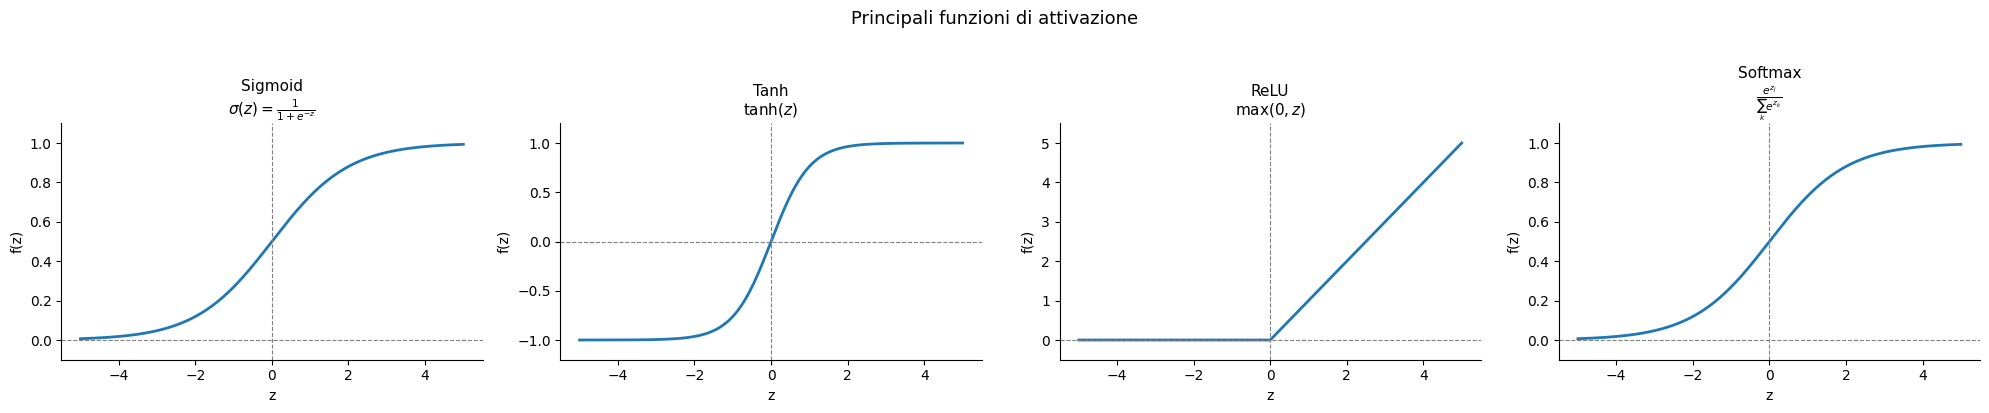

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Activation functions ---

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

def softmax_single(z):
    """Softmax applied to a vector — shown here along a single axis
    with all other logits fixed at zero for visualization purposes."""
    z_vec = np.column_stack([np.zeros_like(z), z])
    e     = np.exp(z_vec - z_vec.max(axis=1, keepdims=True))
    return (e / e.sum(axis=1, keepdims=True))[:, 1]

# --- Plot ---
z = np.linspace(-5, 5, 300)

functions = [
    ('Sigmoid',  sigmoid(z),        r'$\sigma(z) = \frac{1}{1+e^{-z}}$',    (-0.1, 1.1)),
    ('Tanh',     tanh(z),           r'$\tanh(z)$',                           (-1.2, 1.2)),
    ('ReLU',     relu(z),           r'$\max(0, z)$',                         (-0.5, 5.5)),
    ('Softmax',  softmax_single(z), r'$\frac{e^{z_j}}{\sum_k e^{z_k}}$',    (-0.1, 1.1)),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, values, formula, ylim) in zip(axes, functions):
    sns.lineplot(x=z, y=values, ax=ax, linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'{name}\n{formula}', fontsize=11)
    ax.set_xlabel('z')
    ax.set_ylabel('f(z)')
    ax.set_ylim(ylim)

sns.despine()
plt.suptitle('Principali funzioni di attivazione', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Uso di softmax**

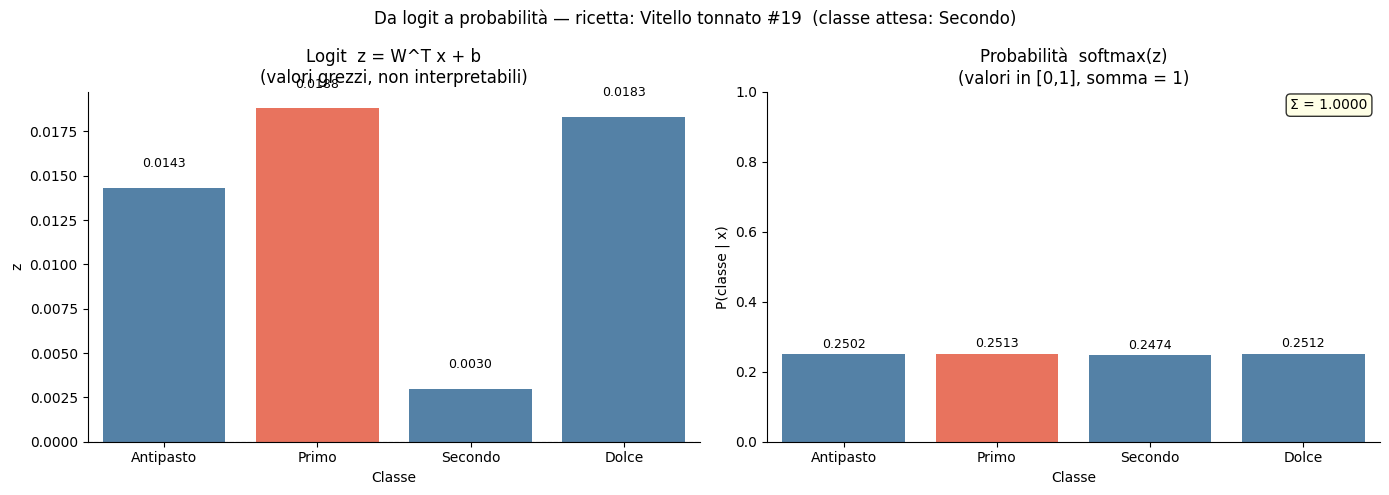

Ricetta:  Vitello tonnato #19
Classe attesa:  Secondo

  Classe           Logit z   P(classe|x)   One-hot atteso
  ----------------------------------------------------
  Antipasto         0.0143        0.2502                0
  Primo             0.0188        0.2513                0
  Secondo           0.0030        0.2474                1 ←
  Dolce             0.0183        0.2512                0

  Somma probabilità: 1.000000
  Predizione:        Primo  ✗


In [4]:
# --- Applying softmax to our logit vector ---

def softmax(z_vec):
    """Softmax function for a vector."""
    e = np.exp(z_vec - np.max(z_vec))  # numerical stability
    return e / e.sum()

# Recompute logits explicitly to avoid naming conflicts
logits = W.T @ x + b
probs  = softmax(logits)

# --- Plot: logits vs probabilities ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_logits = ['tomato' if i == np.argmax(logits) else 'steelblue' for i in range(len(CLASSES))]
colors_probs  = ['tomato' if i == np.argmax(probs)  else 'steelblue' for i in range(len(CLASSES))]

# Left: raw logits
sns.barplot(x=CLASSES, y=logits, hue=CLASSES, palette=colors_logits, legend=False, ax=axes[0])
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_title('Logit  z = W^T x + b\n(valori grezzi, non interpretabili)')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('z')
for i, val in enumerate(logits):
    axes[0].text(i, val + (0.001 if val >= 0 else -0.001),
                 f'{val:.4f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)

# Right: probabilities after softmax
sns.barplot(x=CLASSES, y=probs, hue=CLASSES, palette=colors_probs, legend=False, ax=axes[1])
axes[1].set_title('Probabilità  softmax(z)\n(valori in [0,1], somma = 1)')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('P(classe | x)')
axes[1].set_ylim(0, 1)
for i, val in enumerate(probs):
    axes[1].text(i, val + 0.01, f'{val:.4f}', ha='center', va='bottom', fontsize=9)

axes[1].text(0.98, 0.95, f'Σ = {probs.sum():.4f}',
             transform=axes[1].transAxes, ha='right', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

sns.despine()
plt.suptitle(f'Da logit a probabilità — ricetta: {recipe}  (classe attesa: {label})',
             fontsize=12)
plt.tight_layout()
plt.show()

# --- Numerical summary ---
print(f"Ricetta:  {recipe}")
print(f"Classe attesa:  {label}\n")
print(f"  {'Classe':<12}  {'Logit z':>10}  {'P(classe|x)':>12}  {'One-hot atteso':>15}")
print(f"  {'-'*52}")
for cls, zi, pi, yi in zip(CLASSES, logits, probs, Y_onehot[example_idx]):
    marker = ' ←' if cls == label else ''
    print(f"  {cls:<12}  {zi:>10.4f}  {pi:>12.4f}  {int(yi):>15}{marker}")
print(f"\n  Somma probabilità: {probs.sum():.6f}")
print(f"  Predizione:        {CLASSES[np.argmax(probs)]}  {'✓' if np.argmax(probs) == y[example_idx] else '✗'}")

### Imparare i parametri: discesa del gradiente

La trasformazione lineare che abbiamo costruito dipende interamente dai valori 
di $W$ e $\mathbf{b}$. Al momento questi parametri sono casuali — il modello 
non sa nulla di cucina. L'obiettivo del training è trovare i valori di $W$ e 
$\mathbf{b}$ che producono le predizioni più corrette possibile sull'intero 
training set.

Per farlo abbiamo bisogno di due ingredienti:

- una **funzione di errore** (o *loss*) che misuri quanto le predizioni del 
  modello si discostano dalle etichette corrette — un numero che vogliamo 
  minimizzare
- un **algoritmo di ottimizzazione** che modifichi i parametri nella direzione 
  giusta per ridurre quell'errore

#### La funzione di errore

Per un problema di classificazione multiclasse con output softmax, la funzione 
di errore standard è la **cross-entropy**:

$$\mathcal{L} = -\sum_{j=1}^{K} y_j \log \hat{y}_j$$

dove $\mathbf{y}$ è il vettore one-hot atteso e $\hat{\mathbf{y}}$ è il vettore 
di probabilità prodotto dal modello. Poiché $\mathbf{y}$ è one-hot, la somma 
si riduce a un solo termine: il logaritmo della probabilità assegnata alla 
classe corretta, cambiato di segno. Una probabilità alta per la classe giusta 
produce una loss bassa; una probabilità bassa produce una loss alta.

#### La discesa del gradiente

Immaginiamo la loss come una superficie nello spazio dei parametri: ogni punto 
sulla superficie corrisponde a una configurazione di $W$ e $\mathbf{b}$, e 
l'altezza del punto è il valore della loss in quella configurazione. Vogliamo 
trovare il punto più basso di questa superficie.

Il **gradiente** $\nabla_W \mathcal{L}$ è un vettore che punta nella direzione 
di massima salita della superficie nel punto corrente. Per scendere, dobbiamo 
muoverci nella direzione opposta. La regola di aggiornamento è:

$$W \leftarrow W - \eta \nabla_W \mathcal{L}$$
$$\mathbf{b} \leftarrow \mathbf{b} - \eta \nabla_\mathbf{b} \mathcal{L}$$

dove $\eta$ è il **learning rate**: un iperparametro che controlla quanto 
grande è ogni passo. Un learning rate troppo alto rischia di saltare oltre 
il minimo; uno troppo basso rende l'apprendimento lento.

Questo processo viene ripetuto per molte iterazioni — ogni volta su un 
sottoinsieme del training set (*mini-batch*) o sull'intero dataset — fino 
a convergenza.

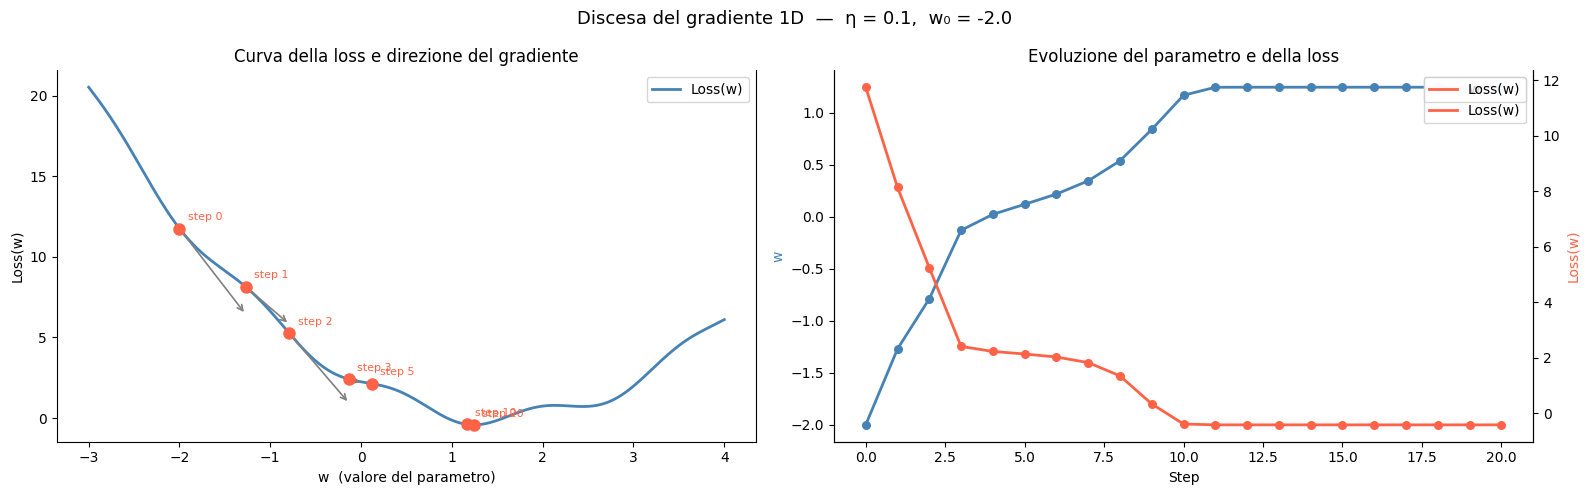

Step           w     Loss(w)        grad    Δw = -η·grad
----------------------------------------------------
0        -2.0000     11.7553     -7.2910          0.7291
1        -1.2709      8.1438     -4.8163          0.4816
2        -0.7893      5.2485     -6.5783          0.6578
3        -0.1314      2.4107     -1.5330          0.1533
4         0.0219      2.2286     -0.9639          0.0964
5         0.1183      2.1370     -0.9831          0.0983
6         0.2166      2.0282     -1.2715          0.1271
7         0.3437      1.8274     -1.9232          0.1923
8         0.5360      1.3493     -3.0128          0.3013
9         0.8373      0.3361     -3.2824          0.3282
10        1.1655     -0.3875     -0.7692          0.0769
11        1.2425     -0.4172     -0.0057          0.0006
12        1.2430     -0.4172     -0.0002          0.0000
13        1.2431     -0.4172     -0.0000          0.0000
14        1.2431     -0.4172     -0.0000          0.0000
15        1.2431     -0.4172     -0

In [5]:
# --- Gradient descent on a single parameter ---
# We reduce the problem to one dimension: a single weight w and its loss.
# This makes the gradient visually interpretable as the slope of the curve.

def loss_1d(w):
    """Simple 1D loss function with a clear minimum."""
    return (w - 1.5) ** 2 + 0.5 * np.sin(4 * w)

def gradient_1d(w):
    """Analytical gradient of loss_1d."""
    return 2 * (w - 1.5) + 2.0 * np.cos(4 * w)

# --- Run gradient descent ---
learning_rate = 0.1
n_steps       = 20
w             = -2.0  # starting point

trajectory = [w]
for _ in range(n_steps):
    w = w - learning_rate * gradient_1d(w)
    trajectory.append(w)

trajectory = np.array(trajectory)
losses_1d  = [loss_1d(w) for w in trajectory]

# --- Plot ---
w_range  = np.linspace(-3, 4, 300)
l_range  = loss_1d(w_range)

# Snapshots to annotate
snapshots = [0, 1, 2, 3, 5, 10, n_steps]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: loss curve with trajectory points and gradient arrows
axes[0].plot(w_range, l_range, color='steelblue', linewidth=2, label='Loss(w)')
for i in snapshots:
    w_i    = trajectory[i]
    l_i    = loss_1d(w_i)
    g_i    = gradient_1d(w_i)
    step_i = learning_rate * g_i

    # Point on curve
    axes[0].plot(w_i, l_i, 'o', color='tomato', markersize=8, zorder=5)
    axes[0].annotate(f'step {i}', (w_i, l_i),
                     textcoords='offset points', xytext=(6, 6),
                     fontsize=8, color='tomato')

    # Gradient arrow — tangent direction
    axes[0].annotate('', 
                     xy=(w_i - step_i, l_i - g_i * step_i),
                     xytext=(w_i, l_i),
                     arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

axes[0].set_title('Curva della loss e direzione del gradiente')
axes[0].set_xlabel('w  (valore del parametro)')
axes[0].set_ylabel('Loss(w)')
axes[0].legend()
sns.despine()

# Right: parameter value and loss over steps
color_w    = 'steelblue'
color_loss = 'tomato'

ax2 = axes[1]
ax3 = ax2.twinx()

sns.lineplot(x=range(len(trajectory)), y=trajectory,
             ax=ax2, color=color_w, linewidth=2, label='w')
ax2.scatter(range(len(trajectory)), trajectory,
            color=color_w, s=30, zorder=5)

sns.lineplot(x=range(len(losses_1d)), y=losses_1d,
             ax=ax3, color=color_loss, linewidth=2, label='Loss(w)')
ax3.scatter(range(len(losses_1d)), losses_1d,
            color=color_loss, s=30, zorder=5)

ax2.set_xlabel('Step')
ax2.set_ylabel('w', color=color_w)
ax3.set_ylabel('Loss(w)', color=color_loss)
ax2.set_title('Evoluzione del parametro e della loss')

lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax2.legend(lines2 + lines3, labels2 + labels3, loc='upper right')
sns.despine(right=False)

plt.suptitle(f'Discesa del gradiente 1D  —  η = {learning_rate},  w₀ = {trajectory[0]:.1f}',
             fontsize=13)
plt.tight_layout()
plt.show()

# --- Step by step numerical trace ---
print(f"{'Step':<6}  {'w':>8}  {'Loss(w)':>10}  {'grad':>10}  {'Δw = -η·grad':>14}")
print(f"{'-'*52}")
for i in range(n_steps + 1):
    w_i    = trajectory[i]
    l_i    = losses_1d[i]
    g_i    = gradient_1d(w_i)
    delta  = -learning_rate * g_i
    print(f"{i:<6}  {w_i:>8.4f}  {l_i:>10.4f}  {g_i:>10.4f}  {delta:>14.4f}")

### Applichiamo l'idea all'apprendimento della nostra rete

Abbiamo tutti gli ingredienti necessari:

- un **vettore di feature** $\mathbf{x}$ che rappresenta ogni ricetta
- una **trasformazione lineare** $W, \mathbf{b}$ che produce i logit
- una **funzione softmax** che converte i logit in probabilità
- una **loss** cross-entropy che misura l'errore rispetto al target one-hot
- la **discesa del gradiente** che aggiorna i parametri nella direzione giusta

Il training loop itera questi passi su tutto il training set per molte epoche.
Ad ogni iterazione eseguiamo due fasi:

- **forward pass** — i dati scorrono in avanti attraverso la rete producendo 
  una predizione e un valore di loss
- **backward pass** — il gradiente della loss rispetto ai parametri viene 
  calcolato e usato per aggiornare $W$ e $\mathbf{b}$

Per la nostra rete senza strati intermedi, il gradiente della cross-entropy 
rispetto ai parametri ha una forma particolarmente elegante. Detto 
$\mathbf{\delta} = \hat{\mathbf{y}} - \mathbf{y}$ l'errore tra probabilità 
predette e target one-hot, i gradienti sono:

$$\nabla_W \mathcal{L} = \mathbf{x} \cdot \mathbf{\delta}^T$$
$$\nabla_\mathbf{b} \mathcal{L} = \mathbf{\delta}$$

L'errore $\mathbf{\delta}$ si propaga direttamente all'indietro: dove il modello 
ha assegnato troppa probabilità a una classe sbagliata, i pesi che connettono 
quegli ingredienti a quella classe vengono ridotti. Dove ha assegnato troppo 
poca probabilità alla classe corretta, vengono aumentati.

In [6]:
# --- Neural network: from scratch ---

def softmax(z):
    """Softmax with numerical stability."""
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def cross_entropy(probs, y_onehot):
    """Mean cross-entropy loss over a batch."""
    n      = probs.shape[0]
    # Clip to avoid log(0)
    clipped = np.clip(probs, 1e-12, 1.0)
    return -np.sum(y_onehot * np.log(clipped)) / n

def forward(X, W, b):
    """Forward pass: linear transformation + softmax."""
    logits = X @ W + b          # shape: (n, 4)
    probs  = softmax(logits)    # shape: (n, 4)
    return logits, probs

def backward(X, probs, y_onehot):
    """Backward pass: compute gradients of cross-entropy loss w.r.t. W and b."""
    n     = X.shape[0]
    delta = (probs - y_onehot) / n   # shape: (n, 4)
    dW    = X.T @ delta              # shape: (10, 4)
    db    = delta.sum(axis=0)        # shape: (4,)
    return dW, db

def accuracy(probs, y_int):
    """Classification accuracy."""
    predictions = np.argmax(probs, axis=1)
    return (predictions == y_int).mean()

def train(X_train, Y_train, y_train,
          X_test,  Y_test,  y_test,
          learning_rate=0.1,
          n_epochs=200,
          snapshot_epochs=None):
    """
    Train a single-layer neural network with gradient descent.
    Returns trained parameters and training history.
    """
    if snapshot_epochs is None:
        snapshot_epochs = [1, 5, 10, 20, 50, 100, n_epochs]

    # Initialize parameters
    np.random.seed(42)
    W = np.random.randn(X_train.shape[1], len(CLASSES)) * 0.01
    b = np.zeros(len(CLASSES))

    history   = {'epoch': [], 'train_loss': [], 'test_loss': [],
                 'train_acc': [], 'test_acc': []}
    snapshots = {}

    for epoch in range(1, n_epochs + 1):

        # --- Forward pass ---
        _, probs_train = forward(X_train, W, b)

        # --- Loss and accuracy ---
        train_loss = cross_entropy(probs_train, Y_train)
        train_acc  = accuracy(probs_train, y_train)

        # --- Backward pass ---
        dW, db = backward(X_train, probs_train, Y_train)

        # --- Parameter update ---
        W -= learning_rate * dW
        b -= learning_rate * db

        # --- Evaluation on test set ---
        _, probs_test = forward(X_test, W, b)
        test_loss     = cross_entropy(probs_test, Y_test)
        test_acc      = accuracy(probs_test, y_test)

        # --- Record history ---
        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        if epoch in snapshot_epochs:
            snapshots[epoch] = {'W': W.copy(), 'b': b.copy(),
                                'train_loss': train_loss, 'test_loss': test_loss,
                                'train_acc': train_acc, 'test_acc': test_acc}

        # --- Progress print ---
        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch:>4}  |  "
                  f"train loss: {train_loss:.4f}  acc: {train_acc:.3f}  |  "
                  f"test  loss: {test_loss:.4f}  acc: {test_acc:.3f}")

    return W, b, history, snapshots


# --- Run training ---
N_EPOCHS      = 200
LEARNING_RATE = 0.1

W_trained, b_trained, history, snapshots = train(
    X_train, Y_train, y_train,
    X_test,  Y_test,  y_test,
    learning_rate = LEARNING_RATE,
    n_epochs      = N_EPOCHS
)

Epoch    1  |  train loss: 1.3873  acc: 0.254  |  test  loss: 1.3720  acc: 0.550
Epoch   20  |  train loss: 1.0591  acc: 0.929  |  test  loss: 1.0911  acc: 0.833
Epoch   40  |  train loss: 0.8376  acc: 0.938  |  test  loss: 0.8972  acc: 0.833
Epoch   60  |  train loss: 0.6940  acc: 0.938  |  test  loss: 0.7703  acc: 0.850
Epoch   80  |  train loss: 0.5966  acc: 0.938  |  test  loss: 0.6845  acc: 0.850
Epoch  100  |  train loss: 0.5276  acc: 0.942  |  test  loss: 0.6245  acc: 0.850
Epoch  120  |  train loss: 0.4767  acc: 0.942  |  test  loss: 0.5810  acc: 0.850
Epoch  140  |  train loss: 0.4379  acc: 0.942  |  test  loss: 0.5484  acc: 0.867
Epoch  160  |  train loss: 0.4074  acc: 0.942  |  test  loss: 0.5234  acc: 0.867
Epoch  180  |  train loss: 0.3828  acc: 0.942  |  test  loss: 0.5038  acc: 0.867
Epoch  200  |  train loss: 0.3627  acc: 0.942  |  test  loss: 0.4881  acc: 0.867


### Valutare il modello: test set e matrice di confusione

Durante il training il modello ha visto le stesse 240 ricette centinaia di 
volte, aggiustando i propri parametri per ridurre l'errore su quegli esempi 
specifici. L'accuratezza sul training set è quindi una misura ottimistica: 
il modello potrebbe aver semplicemente **memorizzato** i dati invece di 
imparare una regola generale.

Per misurare la vera capacità di generalizzazione valutiamo il modello sul 
**test set**: le 60 ricette tenute da parte prima del training, che il modello 
non ha mai visto. 
**A questo punto la rete non impara più, fa solo predizioni su nuove ricette sulla base di ciò che ha imparato dal training set**.
Se le prestazioni sul test set sono simili a quelle sul 
training set, il modello ha imparato qualcosa di genuino. Se c'è un divario 
significativo, il modello ha sovra-adattato — ha imparato a memoria invece 
di generalizzare.

L'accuratezza complessiva è una misura utile ma incompleta: non dice nulla 
su *dove* il modello sbaglia. Per questo usiamo la **matrice di confusione**: 
una tabella in cui le righe rappresentano le classi reali e le colonne le 
classi predette. La cella $(i, j)$ contiene il numero di esempi della classe 
$i$ che il modello ha classificato come classe $j$.

La diagonale principale raccoglie le predizioni corrette. Gli elementi fuori 
diagonale rivelano gli errori sistematici: se la cella *(Primo, Secondo)* 
ha un valore alto, il modello tende a confondere i primi con i secondi — 
un'informazione molto più ricca della sola accuratezza media.

Test set — loss: 0.4881  |  accuratezza: 0.867
Training  — loss: 0.3627  |  accuratezza: 0.942


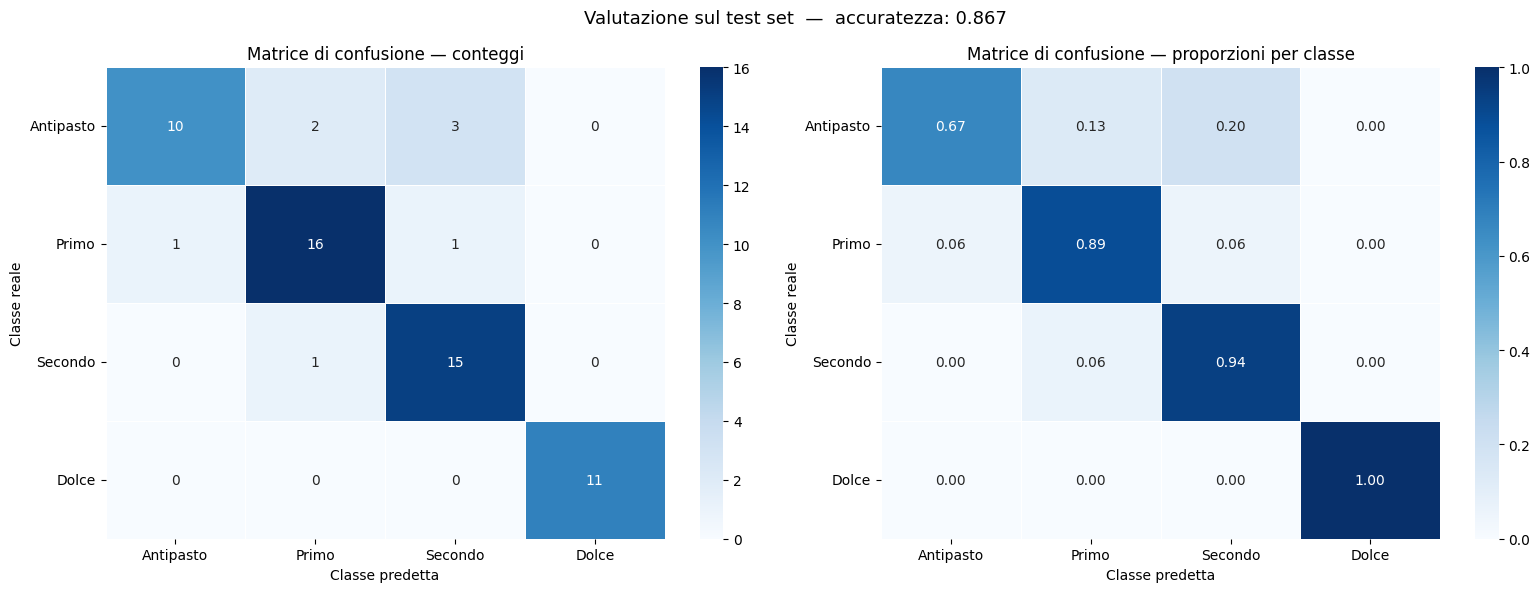


  Classe         Corretti   Totale    Recall   Precision
  ----------------------------------------------------
  Antipasto            10       15     0.667       0.909
  Primo                16       18     0.889       0.842
  Secondo              15       16     0.938       0.789
  Dolce                11       11     1.000       1.000

  Media macro                          0.873       0.885


In [7]:
# --- Evaluation on test set ---

_, probs_test = forward(X_test, W_trained, b_trained)
y_pred        = np.argmax(probs_test, axis=1)

test_acc  = accuracy(probs_test, y_test)
test_loss = cross_entropy(probs_test, Y_test)

print(f"Test set — loss: {test_loss:.4f}  |  accuratezza: {test_acc:.3f}")
print(f"Training  — loss: {history['train_loss'][-1]:.4f}  |  "
      f"accuratezza: {history['train_acc'][-1]:.3f}")

# --- Confusion matrix ---
def confusion_matrix(y_true, y_pred, n_classes):
    """Compute confusion matrix from integer label arrays."""
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for true, pred in zip(y_true, y_pred):
        cm[true, pred] += 1
    return cm

cm = confusion_matrix(y_test, y_pred, len(CLASSES))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: raw counts
sns.heatmap(cm,
            annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Matrice di confusione — conteggi')
axes[0].set_xlabel('Classe predetta')
axes[0].set_ylabel('Classe reale')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Right: normalized by row (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm,
            annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Matrice di confusione — proporzioni per classe')
axes[1].set_xlabel('Classe predetta')
axes[1].set_ylabel('Classe reale')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.suptitle(f'Valutazione sul test set  —  accuratezza: {test_acc:.3f}',
             fontsize=13)
plt.tight_layout()
plt.show()

# --- Per-class summary ---
print(f"\n  {'Classe':<12}  {'Corretti':>9}  {'Totale':>7}  {'Recall':>8}  {'Precision':>10}")
print(f"  {'-'*52}")
for i, cls in enumerate(CLASSES):
    correct   = cm[i, i]
    total_row = cm[i].sum()    # all examples of this class (for recall)
    total_col = cm[:, i].sum() # all examples predicted as this class (for precision)
    recall    = correct / total_row if total_row > 0 else 0
    precision = correct / total_col if total_col > 0 else 0
    print(f"  {cls:<12}  {correct:>9}  {total_row:>7}  {recall:>8.3f}  {precision:>10.3f}")

# --- Macro averages ---
recalls    = [cm[i, i] / cm[i].sum()    for i in range(len(CLASSES)) if cm[i].sum() > 0]
precisions = [cm[i, i] / cm[:, i].sum() for i in range(len(CLASSES)) if cm[:, i].sum() > 0]
print(f"\n  {'Media macro':<12}  {'':>9}  {'':>7}  {np.mean(recalls):>8.3f}  {np.mean(precisions):>10.3f}")

## Approfondimento: la non linearità

La rete che abbiamo costruito è composta da un solo strato lineare. Questo significa 
che la funzione che il modello impara è della forma:

$$f(\mathbf{x}) = W^T \mathbf{x} + \mathbf{b}$$

Una trasformazione lineare ha una proprietà importante — e limitante: qualunque 
composizione di trasformazioni lineari è ancora una trasformazione lineare. 
Aggiungere strati senza funzioni di attivazione non aumenta la capacità espressiva 
del modello — è come sommare più righe di una stessa equazione.

Il problema è che molte relazioni reali tra variabili non sono lineari. 
Consideriamo un esempio semplice: vogliamo stimare il **grado di dolcezza** 
di una ricetta in funzione della quantità di zucchero. Fino a una certa soglia 
la dolcezza cresce rapidamente, poi si stabilizza — il palato satura. 
Una retta non può catturare questo comportamento: qualunque inclinazione 
scegliamo, sarà sempre sbagliata in qualche parte del dominio.

Introducendo una **funzione di attivazione non lineare** — come ReLU o la sigmoide 
— il modello acquisisce la capacità di piegare la propria funzione di risposta, 
adattandosi a relazioni più complesse. Con abbastanza unità e strati, una rete 
neurale con attivazioni non lineari può approssimare qualsiasi funzione continua — 
questo risultato è noto come **teorema di approssimazione universale**.

Nel seguente esempio mostriamo la differenza su un caso 1D: la stessa relazione 
non lineare stimata prima con una regressione lineare, poi con un modello che 
introduce non linearità.

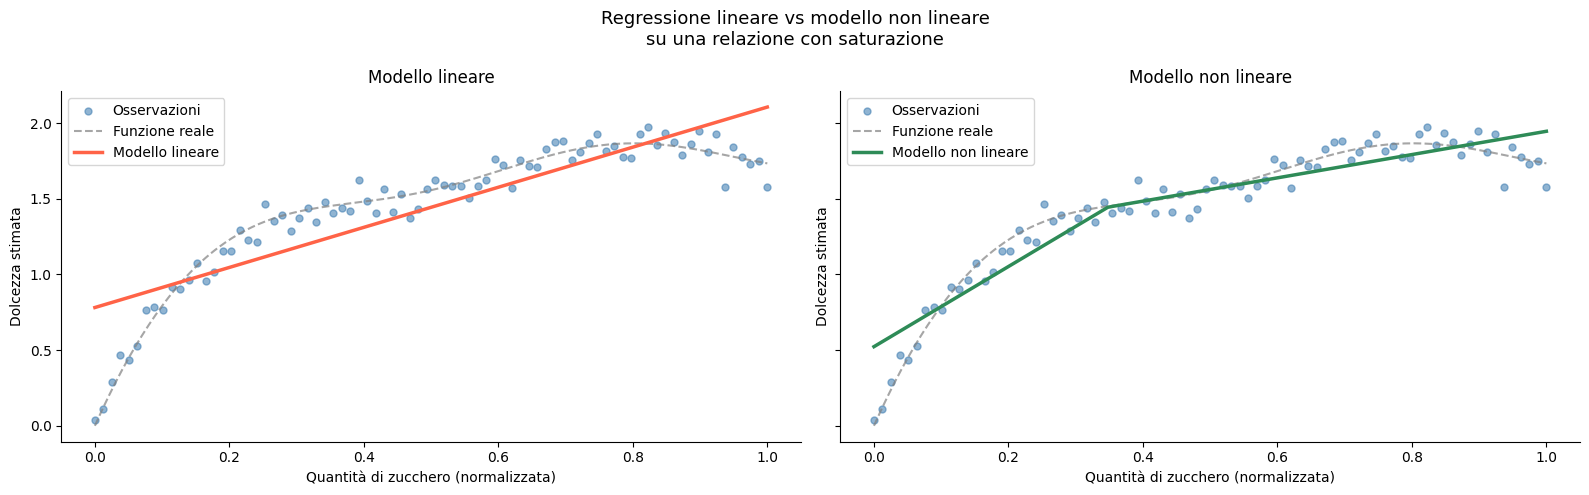

  MSE modello lineare:      0.0476
  MSE modello non lineare:  0.0195
  Riduzione errore:         59.1%


In [8]:
import numpy as np


# --- Non-linearity: 1D example ---
# Simulated relationship: sweetness as a function of sugar quantity
# The true relationship is non-linear (saturating curve with noise)

np.random.seed(42)
n_points = 80

# Input: sugar quantity (normalized 0-1)
x_1d = np.linspace(0, 1, n_points)

# True underlying function: fast growth then saturation
def true_function(x):
    return 1.8 * (1 - np.exp(-5 * x)) + 0.1 * np.sin(10 * x)

y_1d      = true_function(x_1d) + np.random.normal(0, 0.08, n_points)
x_smooth  = np.linspace(0, 1, 300)
y_smooth  = true_function(x_smooth)

# --- Model 1: linear regression ---
# y = w * x + b  (fit with least squares)
A       = np.column_stack([x_1d, np.ones_like(x_1d)])
w_lin   = np.linalg.lstsq(A, y_1d, rcond=None)[0]
y_linear = w_lin[0] * x_smooth + w_lin[1]

# --- Model 2: non-linear model (small MLP, 1 hidden layer with ReLU) ---
# We train it manually with gradient descent to keep things explicit

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def forward_mlp(x, W1, b1, W2, b2):
    """1 hidden layer with ReLU, scalar output."""
    z1 = x[:, None] @ W1[None, :] + b1   # shape: (n, n_hidden)
    a1 = relu(z1)
    z2 = a1 @ W2[:, None] + b2            # shape: (n, 1)
    return z1, a1, z2.squeeze()

n_hidden = 16
np.random.seed(0)
W1_nl = np.random.randn(n_hidden) * 0.1
b1_nl = np.zeros(n_hidden)
W2_nl = np.random.randn(n_hidden) * 0.1
b2_nl = 0.0

lr_nl    = 0.05
n_epochs_nl = 3000

for _ in range(n_epochs_nl):
    z1, a1, y_hat = forward_mlp(x_1d, W1_nl, b1_nl, W2_nl, b2_nl)
    error         = y_hat - y_1d                           # shape: (n,)
    loss_nl       = (error ** 2).mean()

    # Backward
    d_out = 2 * error / len(x_1d)                         # shape: (n,)
    dW2   = a1.T @ d_out                                   # shape: (n_hidden,)
    db2   = d_out.sum()
    d_a1  = d_out[:, None] * W2_nl[None, :]               # shape: (n, n_hidden)
    d_z1  = d_a1 * relu_deriv(z1)                         # shape: (n, n_hidden)
    dW1   = (x_1d[:, None] * d_z1).sum(axis=0)            # shape: (n_hidden,)
    db1   = d_z1.sum(axis=0)

    W2_nl -= lr_nl * dW2
    b2_nl -= lr_nl * db2
    W1_nl -= lr_nl * dW1
    b1_nl -= lr_nl * db1

_, _, y_nonlinear = forward_mlp(x_smooth, W1_nl, b1_nl, W2_nl, b2_nl)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (model_name, y_pred, color) in zip(axes, [
    ('Modello lineare',       y_linear,    'tomato'),
    ('Modello non lineare',   y_nonlinear, 'seagreen'),
]):
    ax.scatter(x_1d, y_1d, color='steelblue', s=25, alpha=0.6, label='Osservazioni')
    ax.plot(x_smooth, y_smooth, color='gray', linewidth=1.5,
            linestyle='--', label='Funzione reale', alpha=0.7)
    ax.plot(x_smooth, y_pred, color=color, linewidth=2.5, label=model_name)
    ax.set_title(model_name)
    ax.set_xlabel('Quantità di zucchero (normalizzata)')
    ax.set_ylabel('Dolcezza stimata')
    ax.legend()
    sns.despine()

plt.suptitle('Regressione lineare vs modello non lineare\n'
             'su una relazione con saturazione', fontsize=13)
plt.tight_layout()
plt.show()

# --- Residuals comparison ---
_, _, y_hat_train_nl = forward_mlp(x_1d, W1_nl, b1_nl, W2_nl, b2_nl)
y_hat_train_lin      = w_lin[0] * x_1d + w_lin[1]

mse_lin = ((y_hat_train_lin - y_1d) ** 2).mean()
mse_nl  = ((y_hat_train_nl  - y_1d) ** 2).mean()

print(f"  MSE modello lineare:      {mse_lin:.4f}")
print(f"  MSE modello non lineare:  {mse_nl:.4f}")
print(f"  Riduzione errore:         {(1 - mse_nl/mse_lin)*100:.1f}%")